<a href="https://colab.research.google.com/github/IremOzbek/Malaria_DINOv2-performansAnalizi/blob/main/Malaria_DenseNet121.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =====================================================
# MALARIA CLASSIFICATION PROJECT
# NIH MALARIA CELL IMAGES DATASET
# BASELINE MODEL: RESNET50
# =====================================================

# -----------------------------
# Install Required Packages
# -----------------------------
!pip -q install kaggle
!pip -q install timm
!pip -q install torchmetrics
!pip -q install seaborn

# -----------------------------
# Imports
# -----------------------------
import os
import random
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# -----------------------------
# Device Check
# -----------------------------
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 50)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU Memory:",
        round(
            torch.cuda.get_device_properties(0).total_memory
            / 1024**3,
            2
        ),
        "GB"
    )

print("=" * 50)

# -----------------------------
# Project Paths
# -----------------------------
PROJECT_NAME = "Malaria_ResNet50"

BASE_DIR = "/content"

DATA_DIR = os.path.join(BASE_DIR, "data")

MODEL_DIR = os.path.join(BASE_DIR, "models")

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

print("Project initialized successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 45.0 MB/s eta 0:00:00
Device: cuda
GPU: NVIDIA L4
GPU Memory: 22.03 GB
Project initialized successfully.


In [2]:
# =====================================================
# KAGGLE API SETUP
# =====================================================

from google.colab import files

print("Upload your kaggle.json file")
uploaded = files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API configured successfully.")

Upload your kaggle.json file


Saving kaggle.json to kaggle.json
Kaggle API configured successfully.


In [3]:
# =====================================================
# DOWNLOAD NIH MALARIA DATASET
# =====================================================

!kaggle datasets download -d iarunava/cell-images-for-detecting-malaria

print("Download completed.")

Dataset URL: https://www.kaggle.com/datasets/iarunava/cell-images-for-detecting-malaria
License(s): unknown
100% 675M/675M [00:40<00:00, 17.3MB/s]

Download completed.


In [4]:
# =====================================================
# EXTRACT DATASET
# =====================================================

import zipfile
import os

ZIP_PATH = "/content/cell-images-for-detecting-malaria.zip"

EXTRACT_PATH = "/content/malaria_dataset"

os.makedirs(EXTRACT_PATH, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("Dataset extracted successfully.")
print("Location:", EXTRACT_PATH)

Dataset extracted successfully.
Location: /content/malaria_dataset


In [5]:
# =====================================================
# CHECK DATASET STRUCTURE
# =====================================================

import os

for root, dirs, files in os.walk("/content/malaria_dataset"):
    print(root)

    if len(files) > 0:
        print("Files:", len(files))

    print("-"*50)

/content/malaria_dataset
--------------------------------------------------
/content/malaria_dataset/cell_images
--------------------------------------------------
/content/malaria_dataset/cell_images/Uninfected
Files: 13780
--------------------------------------------------
/content/malaria_dataset/cell_images/cell_images
--------------------------------------------------
/content/malaria_dataset/cell_images/cell_images/Uninfected
Files: 13780
--------------------------------------------------
/content/malaria_dataset/cell_images/cell_images/Parasitized
Files: 13780
--------------------------------------------------
/content/malaria_dataset/cell_images/Parasitized
Files: 13780
--------------------------------------------------


In [6]:
# =====================================================
# CHECK CLASS FOLDERS
# =====================================================

DATASET_PATH = "/content/malaria_dataset/cell_images/cell_images"

print("Classes found:\n")

for item in os.listdir(DATASET_PATH):
    full_path = os.path.join(DATASET_PATH, item)

    if os.path.isdir(full_path):
        num_images = len(os.listdir(full_path))

        print(f"{item} --> {num_images} images")

Classes found:

Uninfected --> 13780 images
Parasitized --> 13780 images


In [7]:
import os

DATASET_PATH = "/content/malaria_dataset/cell_images/cell_images"

for item in os.listdir(DATASET_PATH):
    full_path = os.path.join(DATASET_PATH, item)

    print(item)

    if os.path.isdir(full_path):
        print("  Folder")

        try:
            print("  Contains:", len(os.listdir(full_path)), "items")
        except:
            pass

    print("-"*40)

Uninfected
  Folder
  Contains: 13780 items
----------------------------------------
Parasitized
  Folder
  Contains: 13780 items
----------------------------------------


In [8]:
# =====================================================
# REMOVE NESTED CELL_IMAGES FOLDER
# =====================================================

import os
import shutil

nested_folder = "/content/malaria_dataset/cell_images/cell_images"

if os.path.exists(nested_folder):
    shutil.rmtree(nested_folder)
    print("Removed:", nested_folder)
else:
    print("Folder not found.")

Removed: /content/malaria_dataset/cell_images/cell_images


In [9]:
# =====================================================
# TRAIN / VALIDATION / TEST SPLIT (80/10/10)
# =====================================================

import os
import shutil
from sklearn.model_selection import train_test_split

SEED = 42

SOURCE_DIR = "/content/malaria_dataset/cell_images"
SPLIT_DIR = "/content/malaria_split"

classes = ["Parasitized", "Uninfected"]

# Klasörleri oluştur
for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(
            os.path.join(SPLIT_DIR, split, cls),
            exist_ok=True
        )

for cls in classes:

    class_dir = os.path.join(SOURCE_DIR, cls)

    images = os.listdir(class_dir)

    train_imgs, temp_imgs = train_test_split(
        images,
        test_size=0.20,
        random_state=SEED
    )

    val_imgs, test_imgs = train_test_split(
        temp_imgs,
        test_size=0.50,
        random_state=SEED
    )

    split_map = {
        "train": train_imgs,
        "val": val_imgs,
        "test": test_imgs
    }

    for split_name, split_images in split_map.items():

        for img in split_images:

            shutil.copy(
                os.path.join(class_dir, img),
                os.path.join(
                    SPLIT_DIR,
                    split_name,
                    cls,
                    img
                )
            )

print("80/10/10 split completed successfully.")

80/10/10 split completed successfully.


In [10]:
# =====================================================
# VERIFY SPLIT
# =====================================================

import os

for split in ["train", "val", "test"]:

    print(f"\n{split.upper()}")

    total = 0

    for cls in ["Parasitized", "Uninfected"]:

        path = os.path.join(
            "/content/malaria_split",
            split,
            cls
        )

        count = len(os.listdir(path))

        total += count

        print(f"{cls}: {count}")

    print("Total:", total)


TRAIN
Parasitized: 11024
Uninfected: 11024
Total: 22048

VAL
Parasitized: 1378
Uninfected: 1378
Total: 2756

TEST
Parasitized: 1378
Uninfected: 1378
Total: 2756


In [11]:
# =====================================================
# IMAGE TRANSFORMS (224x224 + ImageNet Normalization)
# =====================================================

from torchvision import transforms

IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(20),

    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = val_transform

In [12]:
# =====================================================
# DATASET LOADING
# =====================================================

from torchvision.datasets import ImageFolder

BASE_PATH = "/content/malaria_split"

train_dataset = ImageFolder(
    root=f"{BASE_PATH}/train",
    transform=train_transform
)

val_dataset = ImageFolder(
    root=f"{BASE_PATH}/val",
    transform=val_transform
)

test_dataset = ImageFolder(
    root=f"{BASE_PATH}/test",
    transform=test_transform
)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

print("Classes:", train_dataset.classes)

Train: 22047
Val: 2755
Test: 2756
Classes: ['Parasitized', 'Uninfected']


In [13]:
# =====================================================
# DATALOADERS
# =====================================================

from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders ready.")

DataLoaders ready.


In [14]:
# =====================================================
# SANITY CHECK
# =====================================================

import torch

images, labels = next(iter(train_loader))

print("Batch shape:", images.shape)
print("Label shape:", labels.shape)

print("Min pixel value:", images.min().item())
print("Max pixel value:", images.max().item())

Batch shape: torch.Size([32, 3, 224, 224])
Label shape: torch.Size([32])
Min pixel value: -2.1179039478302
Max pixel value: 2.214658737182617


In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    matthews_corrcoef
)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [16]:
from torchvision import models

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 239MB/s]


In [17]:
# =====================================================
# EXPERIMENT CONFIGURATION
# =====================================================

experiment_config = {

    "Model": "ResNet50",

    "Dataset": "NIH Malaria Cell Images",

    "Train Split": "80%",
    "Validation Split": "10%",
    "Test Split": "10%",

    "Input Size": "224x224",

    "Batch Size": 32,

    "Epochs": 100,

    "Optimizer": "AdamW",

    "Learning Rate": 1e-4,

    "Weight Decay": 0.05,

    "Loss Function": "CrossEntropyLoss",

    "Scheduler": "ReduceLROnPlateau",

    "Early Stopping": 10,

    "Random Seed": 42
}

experiment_config

{'Model': 'ResNet50',
 'Dataset': 'NIH Malaria Cell Images',
 'Train Split': '80%',
 'Validation Split': '10%',
 'Test Split': '10%',
 'Input Size': '224x224',
 'Batch Size': 32,
 'Epochs': 100,
 'Optimizer': 'AdamW',
 'Learning Rate': 0.0001,
 'Weight Decay': 0.05,
 'Loss Function': 'CrossEntropyLoss',
 'Scheduler': 'ReduceLROnPlateau',
 'Early Stopping': 10,
 'Random Seed': 42}

In [18]:
# =====================================================
# METRIC STORAGE
# =====================================================

history = {

    "train_loss": [],
    "val_loss": [],

    "train_acc": [],
    "val_acc": [],

    "train_precision": [],
    "val_precision": [],

    "train_recall": [],
    "val_recall": [],

    "train_f1": [],
    "val_f1": [],

    "val_auc": [],
    "val_mcc": [],

    "learning_rate": []
}

In [19]:
# =====================================================
# EARLY STOPPING
# =====================================================

class EarlyStopping:

    def __init__(
        self,
        patience=10,
        save_path="best_resnet50.pth"
    ):

        self.patience = patience
        self.save_path = save_path

        self.best_loss = np.inf

        self.counter = 0

        self.early_stop = False

    def __call__(self, val_loss, model):

        if val_loss < self.best_loss:

            self.best_loss = val_loss

            self.counter = 0

            torch.save(
                model.state_dict(),
                self.save_path
            )

        else:

            self.counter += 1

            if self.counter >= self.patience:

                self.early_stop = True


early_stopping = EarlyStopping(
    patience=10
)

In [20]:
# =====================================================
# OPTIMIZER
# =====================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=0.05
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.1,
    patience=5
)

print("Optimizer Ready")

Optimizer Ready


In [21]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef
)

EPOCHS = 100

for epoch in range(EPOCHS):

    # --------------------------
    # TRAIN
    # --------------------------

    model.train()

    train_loss = 0

    train_preds = []
    train_labels = []

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        preds = outputs.argmax(1)

        train_preds.extend(
            preds.cpu().numpy()
        )

        train_labels.extend(
            labels.cpu().numpy()
        )

    train_loss /= len(train_loader)

    train_acc = accuracy_score(
        train_labels,
        train_preds
    )

    train_precision = precision_score(
        train_labels,
        train_preds
    )

    train_recall = recall_score(
        train_labels,
        train_preds
    )

    train_f1 = f1_score(
        train_labels,
        train_preds
    )

    # --------------------------
    # VALIDATION
    # --------------------------

    model.eval()

    val_loss = 0

    val_preds = []
    val_labels = []
    val_probs = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            val_loss += loss.item()

            probs = torch.softmax(
                outputs,
                dim=1
            )[:,1]

            preds = outputs.argmax(1)

            val_preds.extend(
                preds.cpu().numpy()
            )

            val_labels.extend(
                labels.cpu().numpy()
            )

            val_probs.extend(
                probs.cpu().numpy()
            )

    val_loss /= len(val_loader)

    val_acc = accuracy_score(
        val_labels,
        val_preds
    )

    val_precision = precision_score(
        val_labels,
        val_preds
    )

    val_recall = recall_score(
        val_labels,
        val_preds
    )

    val_f1 = f1_score(
        val_labels,
        val_preds
    )

    val_auc = roc_auc_score(
        val_labels,
        val_probs
    )

    val_mcc = matthews_corrcoef(
        val_labels,
        val_preds
    )

    # --------------------------
    # SAVE HISTORY
    # --------------------------

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    history["train_precision"].append(train_precision)
    history["val_precision"].append(val_precision)

    history["train_recall"].append(train_recall)
    history["val_recall"].append(val_recall)

    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)

    history["val_auc"].append(val_auc)
    history["val_mcc"].append(val_mcc)

    history["learning_rate"].append(
        optimizer.param_groups[0]["lr"]
    )

    scheduler.step(val_loss)

    early_stopping(
        val_loss,
        model
    )

    print(
        f"[{epoch+1:03d}] "
        f"TrainLoss={train_loss:.4f} "
        f"ValLoss={val_loss:.4f} "
        f"Acc={val_acc:.4f} "
        f"F1={val_f1:.4f} "
        f"AUC={val_auc:.4f} "
        f"MCC={val_mcc:.4f}"
    )

    if early_stopping.early_stop:

        print("\nEarly stopping activated.")

        break

[001] TrainLoss=0.1241 ValLoss=0.1123 Acc=0.9561 F1=0.9564 AUC=0.9930 MCC=0.9123
[002] TrainLoss=0.1019 ValLoss=0.1093 Acc=0.9608 F1=0.9606 AUC=0.9927 MCC=0.9216
[003] TrainLoss=0.0920 ValLoss=0.1014 Acc=0.9641 F1=0.9645 AUC=0.9941 MCC=0.9284
[004] TrainLoss=0.0883 ValLoss=0.1154 Acc=0.9626 F1=0.9627 AUC=0.9923 MCC=0.9252
[005] TrainLoss=0.0816 ValLoss=0.0939 Acc=0.9659 F1=0.9658 AUC=0.9951 MCC=0.9318
[006] TrainLoss=0.0800 ValLoss=0.0948 Acc=0.9666 F1=0.9664 AUC=0.9955 MCC=0.9333
[007] TrainLoss=0.0774 ValLoss=0.0862 Acc=0.9659 F1=0.9663 AUC=0.9956 MCC=0.9321
[008] TrainLoss=0.0740 ValLoss=0.0953 Acc=0.9662 F1=0.9665 AUC=0.9941 MCC=0.9326
[009] TrainLoss=0.0734 ValLoss=0.0936 Acc=0.9662 F1=0.9664 AUC=0.9952 MCC=0.9325
[010] TrainLoss=0.0706 ValLoss=0.1199 Acc=0.9590 F1=0.9584 AUC=0.9935 MCC=0.9183
[011] TrainLoss=0.0728 ValLoss=0.1046 Acc=0.9623 F1=0.9623 AUC=0.9943 MCC=0.9245
[012] TrainLoss=0.0698 ValLoss=0.0872 Acc=0.9666 F1=0.9669 AUC=0.9956 MCC=0.9334
[013] TrainLoss=0.0650 ValLo

In [22]:
# =====================================================
# LOAD BEST MODEL
# =====================================================

model.load_state_dict(
    torch.load(
        "best_resnet50.pth"
    )
)

model.eval()

print("Best model loaded.")

Best model loaded.


In [23]:
# =====================================================
# TEST SET EVALUATION
# =====================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    matthews_corrcoef
)

model.eval()

test_preds = []
test_labels = []
test_probs = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)[:,1]

        preds = torch.argmax(outputs, dim=1)

        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())
        test_probs.extend(probs.cpu().numpy())

# Final Metrics

test_acc = accuracy_score(test_labels, test_preds)

test_precision = precision_score(
    test_labels,
    test_preds
)

test_recall = recall_score(
    test_labels,
    test_preds
)

test_f1 = f1_score(
    test_labels,
    test_preds
)

test_auc = roc_auc_score(
    test_labels,
    test_probs
)

test_mcc = matthews_corrcoef(
    test_labels,
    test_preds
)

cm = confusion_matrix(
    test_labels,
    test_preds
)

print("="*60)
print("FINAL TEST RESULTS")
print("="*60)

print(f"Accuracy  : {test_acc:.4f}")
print(f"Precision : {test_precision:.4f}")
print(f"Recall    : {test_recall:.4f}")
print(f"F1 Score  : {test_f1:.4f}")
print(f"ROC-AUC   : {test_auc:.4f}")
print(f"MCC       : {test_mcc:.4f}")

FINAL TEST RESULTS
Accuracy  : 0.9757
Precision : 0.9679
Recall    : 0.9840
F1 Score  : 0.9759
ROC-AUC   : 0.9972
MCC       : 0.9515


In [24]:
import pandas as pd

results_df = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "MCC"
    ],

    "ResNet50":[
        test_acc,
        test_precision,
        test_recall,
        test_f1,
        test_auc,
        test_mcc
    ]
})

results_df

,Metric,ResNet50
0,Accuracy,0.975689
1,Precision,0.967880
2,Recall,0.984035
3,F1 Score,0.975891
4,ROC-AUC,0.997229
5,MCC,0.951511


In [25]:
results_df.to_csv(
    "ResNet50_Test_Results.csv",
    index=False
)

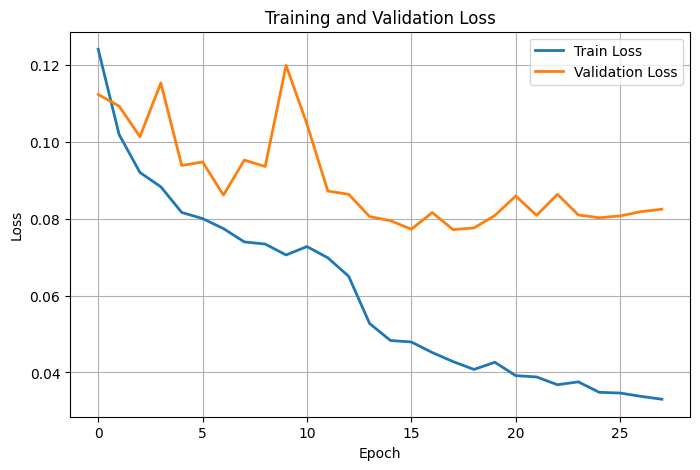

In [26]:
plt.figure(figsize=(8,5))

plt.plot(
    history["train_loss"],
    label="Train Loss",
    linewidth=2
)

plt.plot(
    history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

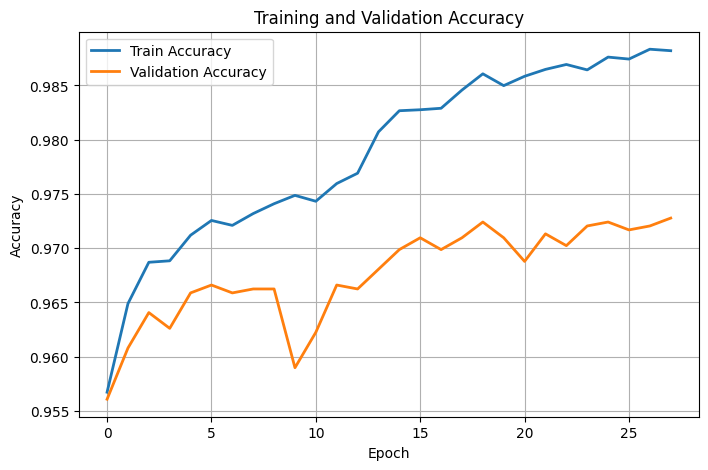

In [27]:
plt.figure(figsize=(8,5))

plt.plot(
    history["train_acc"],
    label="Train Accuracy",
    linewidth=2
)

plt.plot(
    history["val_acc"],
    label="Validation Accuracy",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Training and Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

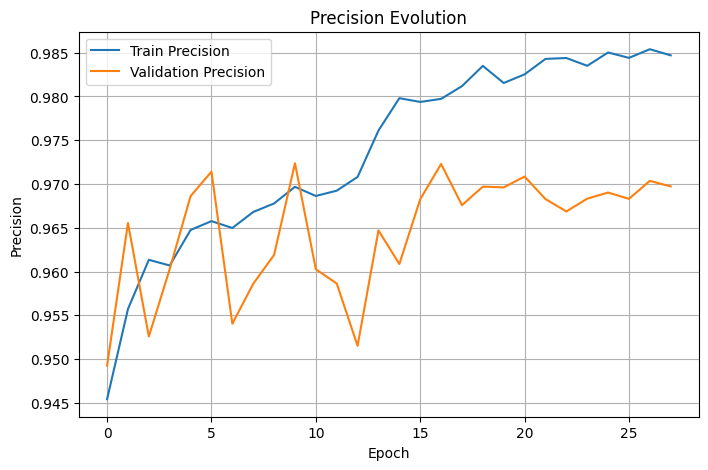

In [28]:
plt.figure(figsize=(8,5))

plt.plot(
    history["train_precision"],
    label="Train Precision"
)

plt.plot(
    history["val_precision"],
    label="Validation Precision"
)

plt.xlabel("Epoch")
plt.ylabel("Precision")

plt.title("Precision Evolution")

plt.legend()
plt.grid(True)

plt.show()

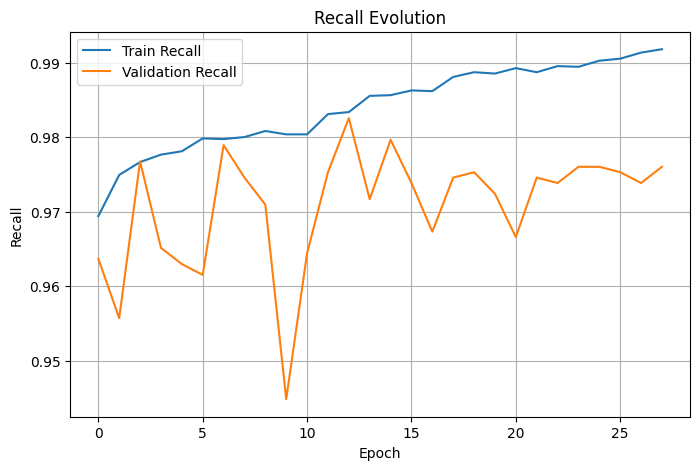

In [29]:
plt.figure(figsize=(8,5))

plt.plot(
    history["train_recall"],
    label="Train Recall"
)

plt.plot(
    history["val_recall"],
    label="Validation Recall"
)

plt.xlabel("Epoch")
plt.ylabel("Recall")

plt.title("Recall Evolution")

plt.legend()
plt.grid(True)

plt.show()

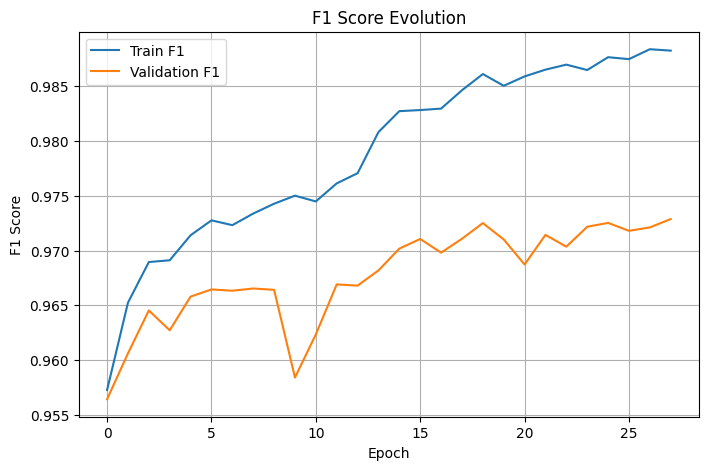

In [30]:
plt.figure(figsize=(8,5))

plt.plot(
    history["train_f1"],
    label="Train F1"
)

plt.plot(
    history["val_f1"],
    label="Validation F1"
)

plt.xlabel("Epoch")
plt.ylabel("F1 Score")

plt.title("F1 Score Evolution")

plt.legend()
plt.grid(True)

plt.show()

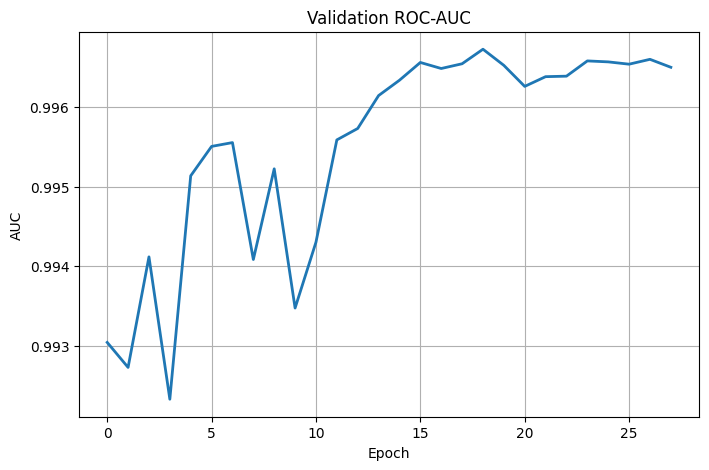

In [31]:
plt.figure(figsize=(8,5))

plt.plot(
    history["val_auc"],
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("AUC")

plt.title("Validation ROC-AUC")

plt.grid(True)

plt.show()

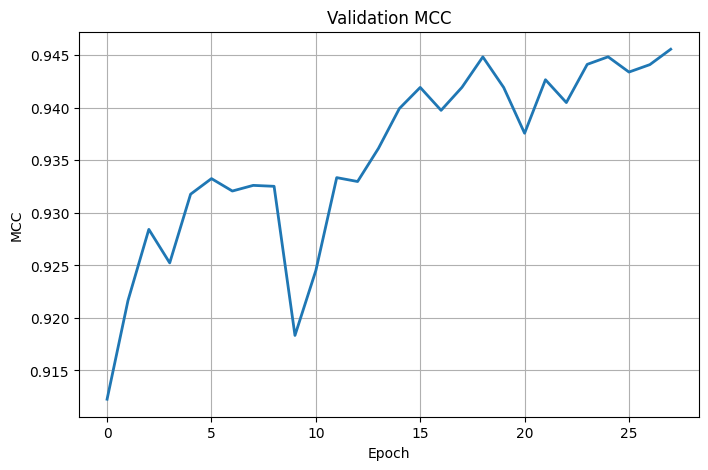

In [32]:
plt.figure(figsize=(8,5))

plt.plot(
    history["val_mcc"],
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("MCC")

plt.title("Validation MCC")

plt.grid(True)

plt.show()

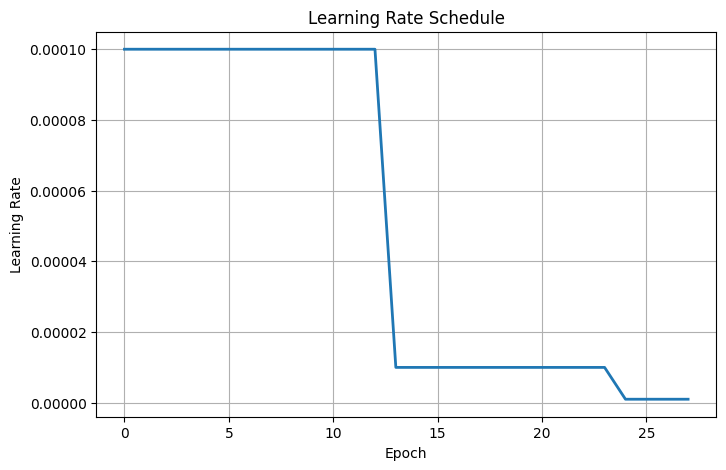

In [33]:
plt.figure(figsize=(8,5))

plt.plot(
    history["learning_rate"],
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Learning Rate")

plt.title("Learning Rate Schedule")

plt.grid(True)

plt.show()

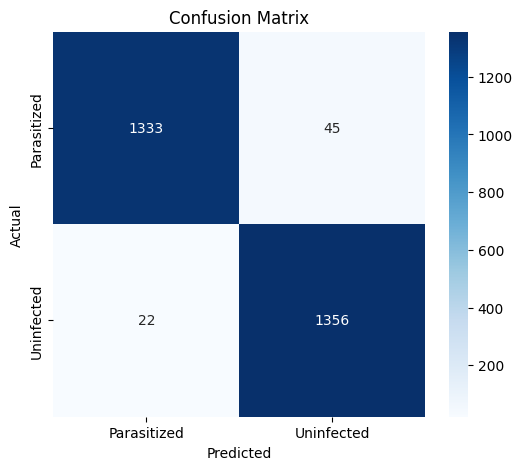

In [34]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    test_labels,
    test_preds
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Parasitized","Uninfected"],
    yticklabels=["Parasitized","Uninfected"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

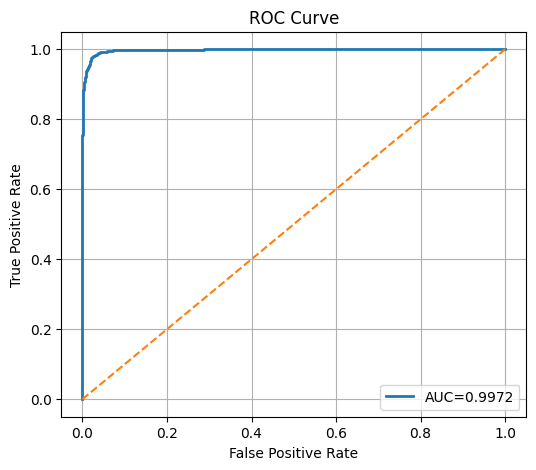

In [35]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(
    test_labels,
    test_probs
)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC={test_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

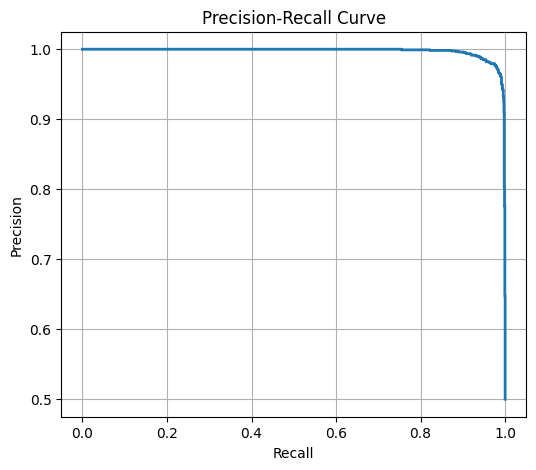

In [36]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(
    test_labels,
    test_probs
)

plt.figure(figsize=(6,5))

plt.plot(
    recall,
    precision,
    linewidth=2
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.grid(True)

plt.show()

In [37]:
# =====================================================
# MODEL 2 : DENSENET121
# =====================================================

In [38]:
# =====================================================
# RESET HISTORY
# =====================================================

history = {

    "train_loss": [],
    "val_loss": [],

    "train_acc": [],
    "val_acc": [],

    "train_precision": [],
    "val_precision": [],

    "train_recall": [],
    "val_recall": [],

    "train_f1": [],
    "val_f1": [],

    "val_auc": [],
    "val_mcc": [],

    "learning_rate": []
}

In [39]:
# =====================================================
# DENSENET121
# =====================================================

from torchvision import models
import torch.nn as nn

model = models.densenet121(
    weights=models.DenseNet121_Weights.IMAGENET1K_V1
)

num_features = model.classifier.in_features

model.classifier = nn.Linear(
    num_features,
    2
)

model = model.to(device)

print(model.classifier)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 230MB/s]


Linear(in_features=1024, out_features=2, bias=True)


In [40]:
# =====================================================
# PARAMETER COUNT
# =====================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Total Parameters:", f"{total_params:,}")
print("Trainable Parameters:", f"{trainable_params:,}")

Total Parameters: 6,955,906
Trainable Parameters: 6,955,906


In [41]:
# =====================================================
# LOSS + OPTIMIZER
# =====================================================

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=0.05
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.1,
    patience=5
)

print("Optimizer Ready")

Optimizer Ready


In [42]:
# =====================================================
# EARLY STOPPING
# =====================================================

early_stopping = EarlyStopping(
    patience=10,
    save_path="best_densenet121.pth"
)

In [43]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef
)

EPOCHS = 100

for epoch in range(EPOCHS):

    # --------------------------
    # TRAIN
    # --------------------------

    model.train()

    train_loss = 0

    train_preds = []
    train_labels = []

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        preds = outputs.argmax(1)

        train_preds.extend(
            preds.cpu().numpy()
        )

        train_labels.extend(
            labels.cpu().numpy()
        )

    train_loss /= len(train_loader)

    train_acc = accuracy_score(
        train_labels,
        train_preds
    )

    train_precision = precision_score(
        train_labels,
        train_preds
    )

    train_recall = recall_score(
        train_labels,
        train_preds
    )

    train_f1 = f1_score(
        train_labels,
        train_preds
    )

    # --------------------------
    # VALIDATION
    # --------------------------

    model.eval()

    val_loss = 0

    val_preds = []
    val_labels = []
    val_probs = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            val_loss += loss.item()

            probs = torch.softmax(
                outputs,
                dim=1
            )[:,1]

            preds = outputs.argmax(1)

            val_preds.extend(
                preds.cpu().numpy()
            )

            val_labels.extend(
                labels.cpu().numpy()
            )

            val_probs.extend(
                probs.cpu().numpy()
            )

    val_loss /= len(val_loader)

    val_acc = accuracy_score(
        val_labels,
        val_preds
    )

    val_precision = precision_score(
        val_labels,
        val_preds
    )

    val_recall = recall_score(
        val_labels,
        val_preds
    )

    val_f1 = f1_score(
        val_labels,
        val_preds
    )

    val_auc = roc_auc_score(
        val_labels,
        val_probs
    )

    val_mcc = matthews_corrcoef(
        val_labels,
        val_preds
    )

    # --------------------------
    # SAVE HISTORY
    # --------------------------

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    history["train_precision"].append(train_precision)
    history["val_precision"].append(val_precision)

    history["train_recall"].append(train_recall)
    history["val_recall"].append(val_recall)

    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)

    history["val_auc"].append(val_auc)
    history["val_mcc"].append(val_mcc)

    history["learning_rate"].append(
        optimizer.param_groups[0]["lr"]
    )

    scheduler.step(val_loss)

    early_stopping(
        val_loss,
        model
    )

    print(
        f"[{epoch+1:03d}] "
        f"TrainLoss={train_loss:.4f} "
        f"ValLoss={val_loss:.4f} "
        f"Acc={val_acc:.4f} "
        f"F1={val_f1:.4f} "
        f"AUC={val_auc:.4f} "
        f"MCC={val_mcc:.4f}"
    )

    if early_stopping.early_stop:

        print("\nEarly stopping activated.")

        break

[001] TrainLoss=0.1164 ValLoss=0.1255 Acc=0.9532 F1=0.9525 AUC=0.9922 MCC=0.9068
[002] TrainLoss=0.0901 ValLoss=0.1041 Acc=0.9644 F1=0.9647 AUC=0.9932 MCC=0.9289
[003] TrainLoss=0.0818 ValLoss=0.0957 Acc=0.9666 F1=0.9668 AUC=0.9945 MCC=0.9333
[004] TrainLoss=0.0770 ValLoss=0.0953 Acc=0.9666 F1=0.9669 AUC=0.9951 MCC=0.9334
[005] TrainLoss=0.0726 ValLoss=0.0918 Acc=0.9677 F1=0.9679 AUC=0.9951 MCC=0.9355
[006] TrainLoss=0.0707 ValLoss=0.0887 Acc=0.9681 F1=0.9680 AUC=0.9950 MCC=0.9361
[007] TrainLoss=0.0672 ValLoss=0.0836 Acc=0.9710 F1=0.9712 AUC=0.9956 MCC=0.9420
[008] TrainLoss=0.0626 ValLoss=0.0946 Acc=0.9633 F1=0.9638 AUC=0.9949 MCC=0.9269
[009] TrainLoss=0.0629 ValLoss=0.0973 Acc=0.9641 F1=0.9648 AUC=0.9955 MCC=0.9289
[010] TrainLoss=0.0592 ValLoss=0.0982 Acc=0.9702 F1=0.9705 AUC=0.9951 MCC=0.9407
[011] TrainLoss=0.0594 ValLoss=0.0999 Acc=0.9641 F1=0.9640 AUC=0.9954 MCC=0.9281
[012] TrainLoss=0.0559 ValLoss=0.0873 Acc=0.9684 F1=0.9687 AUC=0.9953 MCC=0.9370
[013] TrainLoss=0.0539 ValLo

In [44]:
# =====================================================
# LOAD BEST MODEL
# =====================================================

model.load_state_dict(
    torch.load(
        "best_densenet121.pth"
    )
)

model.eval()

print("Best DenseNet121 loaded.")

Best DenseNet121 loaded.


In [45]:
# =====================================================
# DENSENET121 TEST EVALUATION
# =====================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    matthews_corrcoef,
    classification_report
)

model.eval()

test_preds = []
test_labels = []
test_probs = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probs = torch.softmax(
            outputs,
            dim=1
        )[:,1]

        preds = outputs.argmax(1)

        test_preds.extend(
            preds.cpu().numpy()
        )

        test_labels.extend(
            labels.cpu().numpy()
        )

        test_probs.extend(
            probs.cpu().numpy()
        )

# =====================================================
# FINAL METRICS
# =====================================================

test_acc = accuracy_score(
    test_labels,
    test_preds
)

test_precision = precision_score(
    test_labels,
    test_preds
)

test_recall = recall_score(
    test_labels,
    test_preds
)

test_f1 = f1_score(
    test_labels,
    test_preds
)

test_auc = roc_auc_score(
    test_labels,
    test_probs
)

test_mcc = matthews_corrcoef(
    test_labels,
    test_preds
)

cm = confusion_matrix(
    test_labels,
    test_preds
)

print("="*60)
print("DENSENET121 TEST RESULTS")
print("="*60)

print(f"Accuracy  : {test_acc:.4f}")
print(f"Precision : {test_precision:.4f}")
print(f"Recall    : {test_recall:.4f}")
print(f"F1 Score  : {test_f1:.4f}")
print(f"ROC-AUC   : {test_auc:.4f}")
print(f"MCC       : {test_mcc:.4f}")

print("\nClassification Report\n")

print(
    classification_report(
        test_labels,
        test_preds,
        target_names=[
            "Parasitized",
            "Uninfected"
        ]
    )
)

DENSENET121 TEST RESULTS
Accuracy  : 0.9768
Precision : 0.9706
Recall    : 0.9833
F1 Score  : 0.9769
ROC-AUC   : 0.9968
MCC       : 0.9536

Classification Report

              precision    recall  f1-score   support

 Parasitized       0.98      0.97      0.98      1378
  Uninfected       0.97      0.98      0.98      1378

    accuracy                           0.98      2756
   macro avg       0.98      0.98      0.98      2756
weighted avg       0.98      0.98      0.98      2756



In [46]:
# =====================================================
# RESULTS TABLE
# =====================================================

import pandas as pd

DenseNet121_results = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "MCC"
    ],

    "DenseNet121":[

        test_acc,
        test_precision,
        test_recall,
        test_f1,
        test_auc,
        test_mcc
    ]
})

DenseNet121_results

,Metric,DenseNet121
0,Accuracy,0.976778
1,Precision,0.970630
2,Recall,0.983309
3,F1 Score,0.976929
4,ROC-AUC,0.996791
5,MCC,0.953637


In [47]:
DenseNet121_results.to_csv(
    "DenseNet121_Test_Results.csv",
    index=False
)

print("Results saved.")

Results saved.


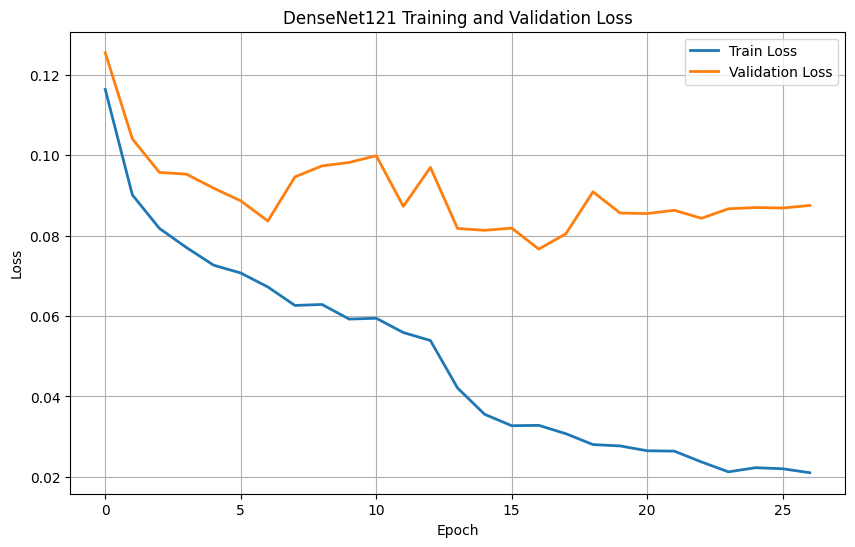

In [48]:
plt.figure(figsize=(10,6))

plt.plot(
    history["train_loss"],
    label="Train Loss",
    linewidth=2
)

plt.plot(
    history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "DenseNet121 Training and Validation Loss"
)

plt.legend()
plt.grid(True)

plt.show()

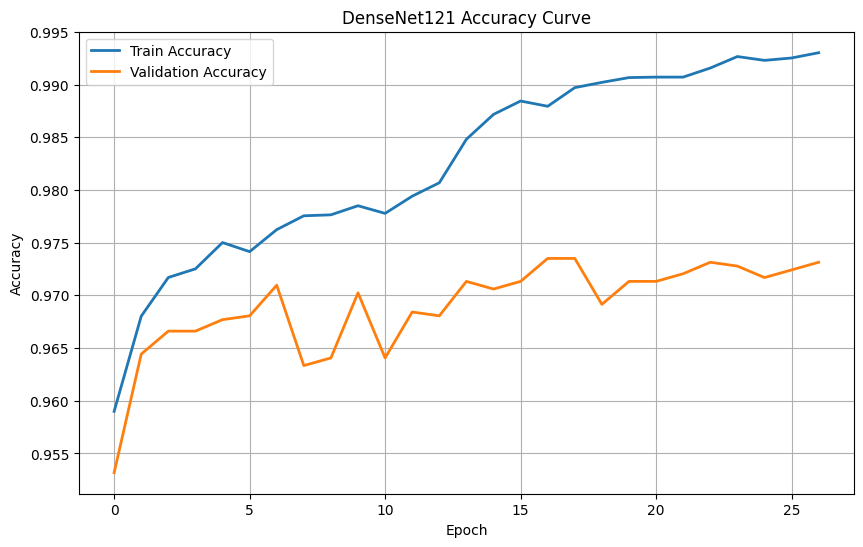

In [49]:
plt.figure(figsize=(10,6))

plt.plot(
    history["train_acc"],
    label="Train Accuracy",
    linewidth=2
)

plt.plot(
    history["val_acc"],
    label="Validation Accuracy",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "DenseNet121 Accuracy Curve"
)

plt.legend()
plt.grid(True)

plt.show()

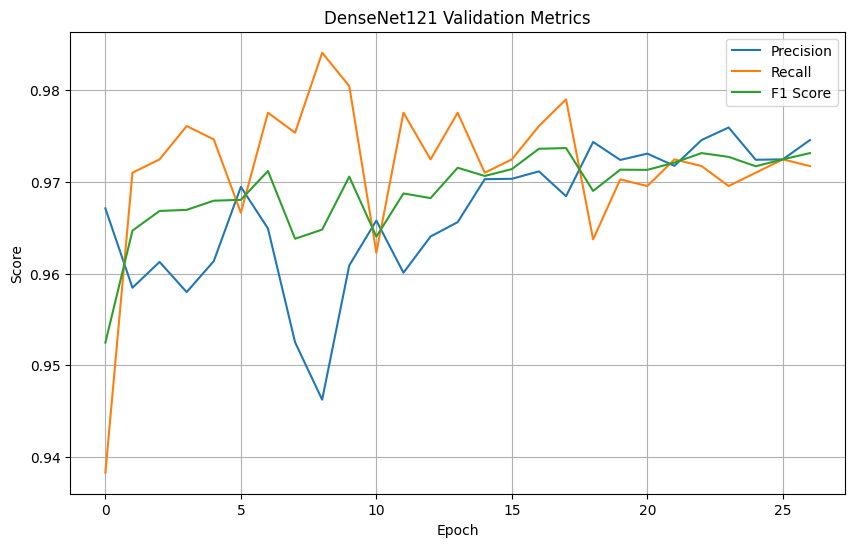

In [50]:
fig, ax = plt.subplots(
    figsize=(10,6)
)

ax.plot(
    history["val_precision"],
    label="Precision"
)

ax.plot(
    history["val_recall"],
    label="Recall"
)

ax.plot(
    history["val_f1"],
    label="F1 Score"
)

ax.set_title(
    "DenseNet121 Validation Metrics"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Score")

ax.legend()

ax.grid(True)

plt.show()

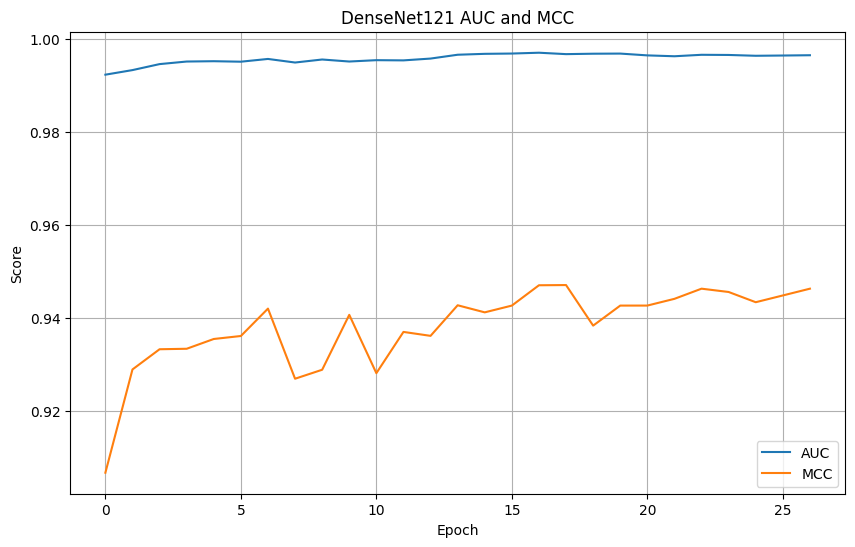

In [51]:
fig, ax = plt.subplots(
    figsize=(10,6)
)

ax.plot(
    history["val_auc"],
    label="AUC"
)

ax.plot(
    history["val_mcc"],
    label="MCC"
)

ax.set_title(
    "DenseNet121 AUC and MCC"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Score")

ax.legend()

ax.grid(True)

plt.show()

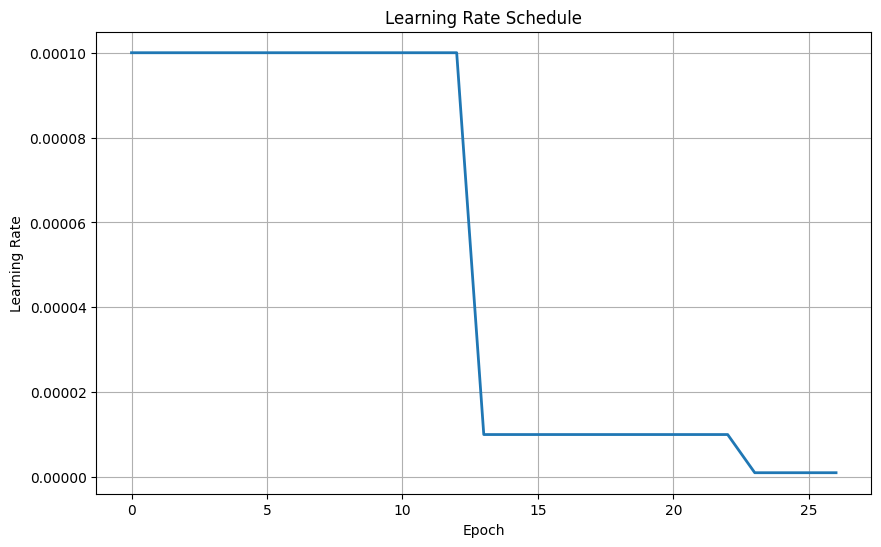

In [52]:
plt.figure(figsize=(10,6))

plt.plot(
    history["learning_rate"],
    linewidth=2
)

plt.title(
    "Learning Rate Schedule"
)

plt.xlabel("Epoch")
plt.ylabel("Learning Rate")

plt.grid(True)

plt.show()

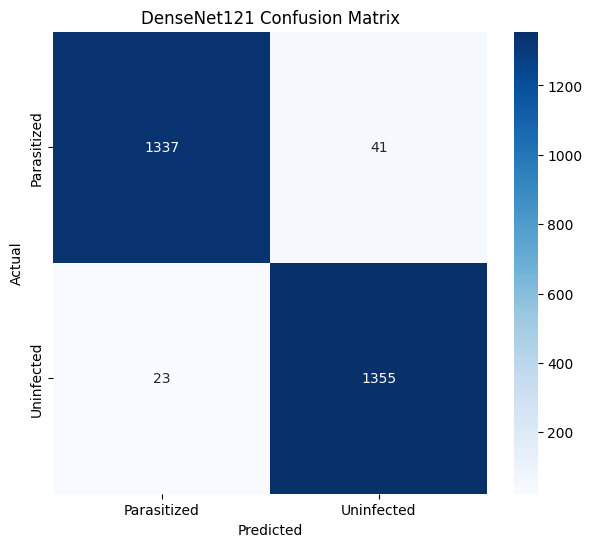

In [53]:
import seaborn as sns

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Parasitized",
        "Uninfected"
    ],
    yticklabels=[
        "Parasitized",
        "Uninfected"
    ]
)

plt.title(
    "DenseNet121 Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

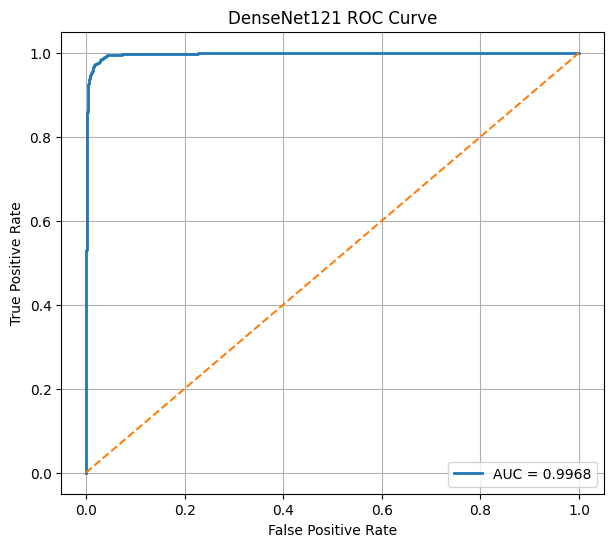

In [54]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(
    test_labels,
    test_probs
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {test_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "DenseNet121 ROC Curve"
)

plt.legend()

plt.grid(True)

plt.show()

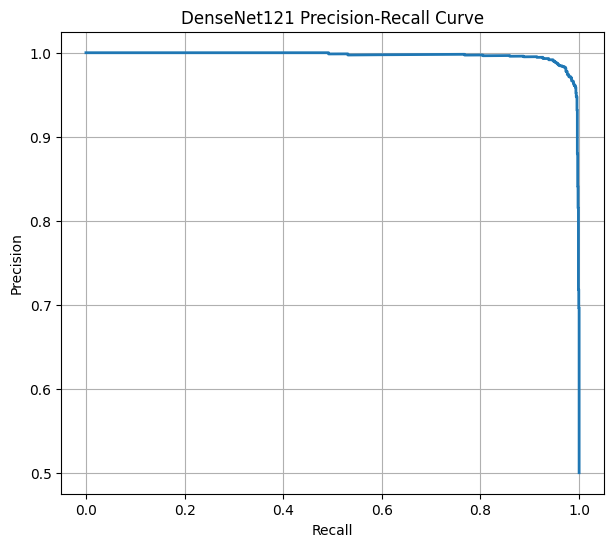

In [55]:
from sklearn.metrics import (
    precision_recall_curve
)

precision_curve, recall_curve, _ = precision_recall_curve(
    test_labels,
    test_probs
)

plt.figure(figsize=(7,6))

plt.plot(
    recall_curve,
    precision_curve,
    linewidth=2
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "DenseNet121 Precision-Recall Curve"
)

plt.grid(True)

plt.show()

In [57]:
# =====================================================
# RESET HISTORY
# =====================================================

history = {

    "train_loss": [],
    "val_loss": [],

    "train_acc": [],
    "val_acc": [],

    "train_precision": [],
    "val_precision": [],

    "train_recall": [],
    "val_recall": [],

    "train_f1": [],
    "val_f1": [],

    "val_auc": [],
    "val_mcc": [],

    "learning_rate": []
}

In [58]:
# =====================================================
# EFFICIENTNET-B3
# =====================================================

from torchvision import models
import torch.nn as nn

model = models.efficientnet_b3(
    weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1
)

in_features = model.classifier[1].in_features

model.classifier[1] = nn.Linear(
    in_features,
    2
)

model = model.to(device)

print(model.classifier)

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 222MB/s]


Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1536, out_features=2, bias=True)
)


In [59]:
# =====================================================
# PARAMETER COUNT
# =====================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

Total Parameters: 10,699,306
Trainable Parameters: 10,699,306


In [60]:
# =====================================================
# LOSS + OPTIMIZER
# =====================================================

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=0.05
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.1,
    patience=5
)

print("Optimizer Ready")

Optimizer Ready


In [61]:
# =====================================================
# EARLY STOPPING
# =====================================================

early_stopping = EarlyStopping(
    patience=10,
    save_path="best_efficientnet_b3.pth"
)

In [62]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef
)

EPOCHS = 100

for epoch in range(EPOCHS):

    # --------------------------
    # TRAIN
    # --------------------------

    model.train()

    train_loss = 0

    train_preds = []
    train_labels = []

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        preds = outputs.argmax(1)

        train_preds.extend(
            preds.cpu().numpy()
        )

        train_labels.extend(
            labels.cpu().numpy()
        )

    train_loss /= len(train_loader)

    train_acc = accuracy_score(
        train_labels,
        train_preds
    )

    train_precision = precision_score(
        train_labels,
        train_preds
    )

    train_recall = recall_score(
        train_labels,
        train_preds
    )

    train_f1 = f1_score(
        train_labels,
        train_preds
    )

    # --------------------------
    # VALIDATION
    # --------------------------

    model.eval()

    val_loss = 0

    val_preds = []
    val_labels = []
    val_probs = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            val_loss += loss.item()

            probs = torch.softmax(
                outputs,
                dim=1
            )[:,1]

            preds = outputs.argmax(1)

            val_preds.extend(
                preds.cpu().numpy()
            )

            val_labels.extend(
                labels.cpu().numpy()
            )

            val_probs.extend(
                probs.cpu().numpy()
            )

    val_loss /= len(val_loader)

    val_acc = accuracy_score(
        val_labels,
        val_preds
    )

    val_precision = precision_score(
        val_labels,
        val_preds
    )

    val_recall = recall_score(
        val_labels,
        val_preds
    )

    val_f1 = f1_score(
        val_labels,
        val_preds
    )

    val_auc = roc_auc_score(
        val_labels,
        val_probs
    )

    val_mcc = matthews_corrcoef(
        val_labels,
        val_preds
    )

    # --------------------------
    # SAVE HISTORY
    # --------------------------

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    history["train_precision"].append(train_precision)
    history["val_precision"].append(val_precision)

    history["train_recall"].append(train_recall)
    history["val_recall"].append(val_recall)

    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)

    history["val_auc"].append(val_auc)
    history["val_mcc"].append(val_mcc)

    history["learning_rate"].append(
        optimizer.param_groups[0]["lr"]
    )

    scheduler.step(val_loss)

    early_stopping(
        val_loss,
        model
    )

    print(
        f"[{epoch+1:03d}] "
        f"TrainLoss={train_loss:.4f} "
        f"ValLoss={val_loss:.4f} "
        f"Acc={val_acc:.4f} "
        f"F1={val_f1:.4f} "
        f"AUC={val_auc:.4f} "
        f"MCC={val_mcc:.4f}"
    )

    if early_stopping.early_stop:

        print("\nEarly stopping activated.")

        break

[001] TrainLoss=0.1326 ValLoss=0.0981 Acc=0.9670 F1=0.9671 AUC=0.9939 MCC=0.9340
[002] TrainLoss=0.0825 ValLoss=0.0922 Acc=0.9662 F1=0.9665 AUC=0.9950 MCC=0.9326
[003] TrainLoss=0.0691 ValLoss=0.0884 Acc=0.9673 F1=0.9672 AUC=0.9961 MCC=0.9347
[004] TrainLoss=0.0632 ValLoss=0.0838 Acc=0.9684 F1=0.9684 AUC=0.9962 MCC=0.9368
[005] TrainLoss=0.0551 ValLoss=0.0877 Acc=0.9699 F1=0.9699 AUC=0.9961 MCC=0.9398
[006] TrainLoss=0.0510 ValLoss=0.0987 Acc=0.9702 F1=0.9702 AUC=0.9962 MCC=0.9405
[007] TrainLoss=0.0465 ValLoss=0.0825 Acc=0.9710 F1=0.9711 AUC=0.9965 MCC=0.9420
[008] TrainLoss=0.0430 ValLoss=0.0901 Acc=0.9706 F1=0.9709 AUC=0.9961 MCC=0.9413
[009] TrainLoss=0.0388 ValLoss=0.0907 Acc=0.9695 F1=0.9697 AUC=0.9959 MCC=0.9391
[010] TrainLoss=0.0396 ValLoss=0.0875 Acc=0.9695 F1=0.9697 AUC=0.9956 MCC=0.9391
[011] TrainLoss=0.0342 ValLoss=0.1118 Acc=0.9699 F1=0.9698 AUC=0.9949 MCC=0.9398
[012] TrainLoss=0.0315 ValLoss=0.0980 Acc=0.9691 F1=0.9691 AUC=0.9960 MCC=0.9383
[013] TrainLoss=0.0292 ValLo

In [63]:
# =====================================================
# LOAD BEST MODEL
# =====================================================

model.load_state_dict(
    torch.load(
        "best_efficientnet_b3.pth"
    )
)

model.eval()

print("Best EfficientNet-B3 loaded.")

Best EfficientNet-B3 loaded.


In [64]:
# =====================================================
# EFFICIENTNET-B3TEST EVALUATION
# =====================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    matthews_corrcoef,
    classification_report
)

model.eval()

test_preds = []
test_labels = []
test_probs = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probs = torch.softmax(
            outputs,
            dim=1
        )[:,1]

        preds = outputs.argmax(1)

        test_preds.extend(
            preds.cpu().numpy()
        )

        test_labels.extend(
            labels.cpu().numpy()
        )

        test_probs.extend(
            probs.cpu().numpy()
        )

# =====================================================
# FINAL METRICS
# =====================================================

test_acc = accuracy_score(
    test_labels,
    test_preds
)

test_precision = precision_score(
    test_labels,
    test_preds
)

test_recall = recall_score(
    test_labels,
    test_preds
)

test_f1 = f1_score(
    test_labels,
    test_preds
)

test_auc = roc_auc_score(
    test_labels,
    test_probs
)

test_mcc = matthews_corrcoef(
    test_labels,
    test_preds
)

cm = confusion_matrix(
    test_labels,
    test_preds
)

print("="*60)
print("EFFICIENTNET-B3 TEST RESULTS")
print("="*60)

print(f"Accuracy  : {test_acc:.4f}")
print(f"Precision : {test_precision:.4f}")
print(f"Recall    : {test_recall:.4f}")
print(f"F1 Score  : {test_f1:.4f}")
print(f"ROC-AUC   : {test_auc:.4f}")
print(f"MCC       : {test_mcc:.4f}")

print("\nClassification Report\n")

print(
    classification_report(
        test_labels,
        test_preds,
        target_names=[
            "Parasitized",
            "Uninfected"
        ]
    )
)

EFFICIENTNET-B3 TEST RESULTS
Accuracy  : 0.9771
Precision : 0.9713
Recall    : 0.9833
F1 Score  : 0.9773
ROC-AUC   : 0.9977
MCC       : 0.9544

Classification Report

              precision    recall  f1-score   support

 Parasitized       0.98      0.97      0.98      1378
  Uninfected       0.97      0.98      0.98      1378

    accuracy                           0.98      2756
   macro avg       0.98      0.98      0.98      2756
weighted avg       0.98      0.98      0.98      2756



In [65]:
efficientnet_results = {

    "Accuracy": test_acc,
    "Precision": test_precision,
    "Recall": test_recall,
    "F1": test_f1,
    "ROC-AUC": test_auc,
    "MCC": test_mcc
}

In [66]:
import pandas as pd

EfficientNetB3_results = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "MCC"
    ],

    "EfficientNet-B3":[

        test_acc,
        test_precision,
        test_recall,
        test_f1,
        test_auc,
        test_mcc
    ]
})

EfficientNetB3_results

,Metric,EfficientNet-B3
0,Accuracy,0.977141
1,Precision,0.971326
2,Recall,0.983309
3,F1 Score,0.977281
4,ROC-AUC,0.997687
5,MCC,0.954354


In [67]:
EfficientNetB3_results.to_csv(
    "EfficientNetB3_Test_Results.csv",
    index=False
)

print("Saved.")

Saved.


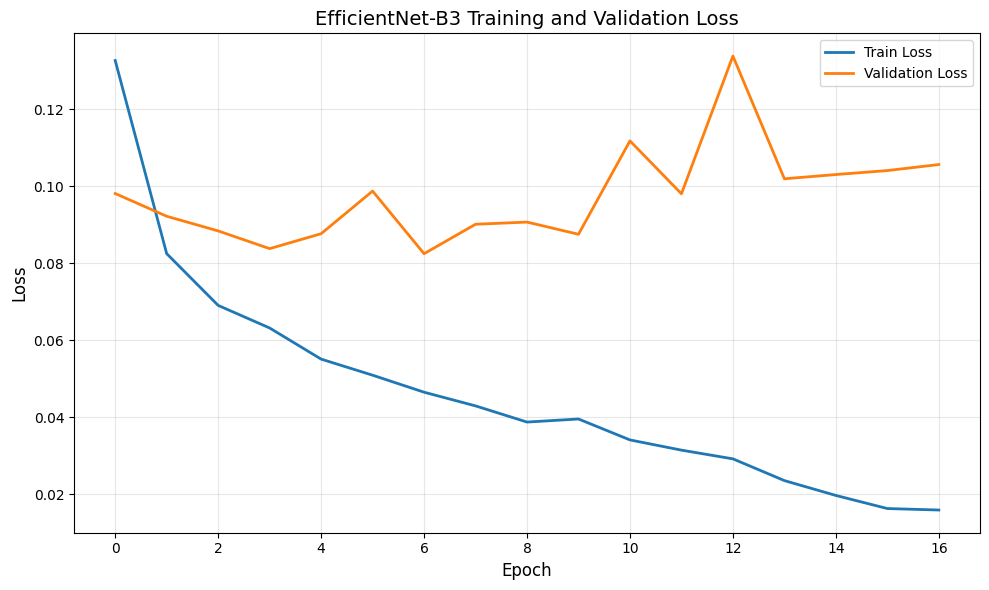

In [68]:
# =====================================================
# LOSS CURVE
# =====================================================

plt.figure(figsize=(10,6))

plt.plot(
    history["train_loss"],
    label="Train Loss",
    linewidth=2
)

plt.plot(
    history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)

plt.title(
    "EfficientNet-B3 Training and Validation Loss",
    fontsize=14
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

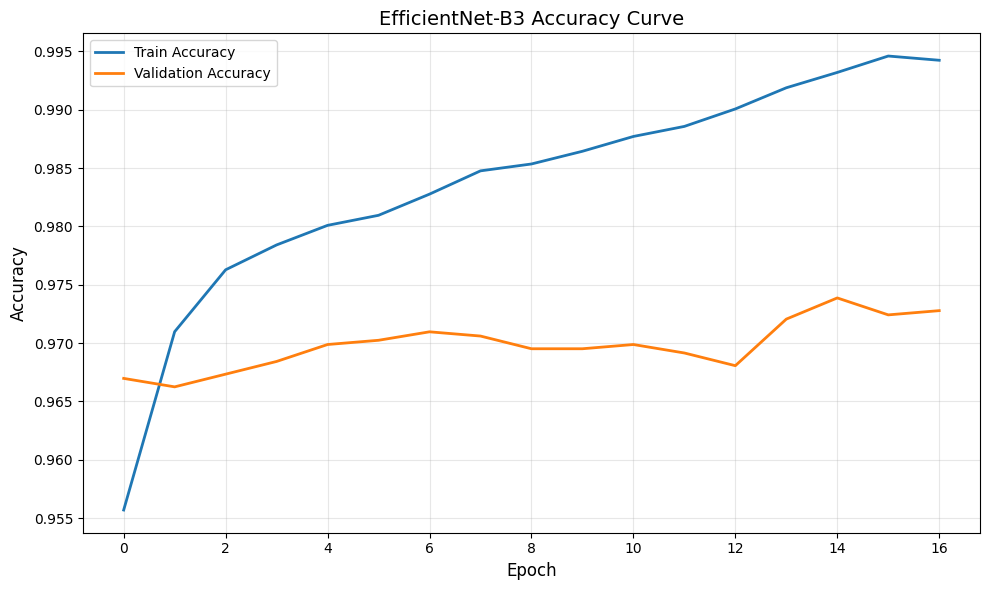

In [69]:
# =====================================================
# ACCURACY CURVE
# =====================================================

plt.figure(figsize=(10,6))

plt.plot(
    history["train_acc"],
    label="Train Accuracy",
    linewidth=2
)

plt.plot(
    history["val_acc"],
    label="Validation Accuracy",
    linewidth=2
)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)

plt.title(
    "EfficientNet-B3 Accuracy Curve",
    fontsize=14
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

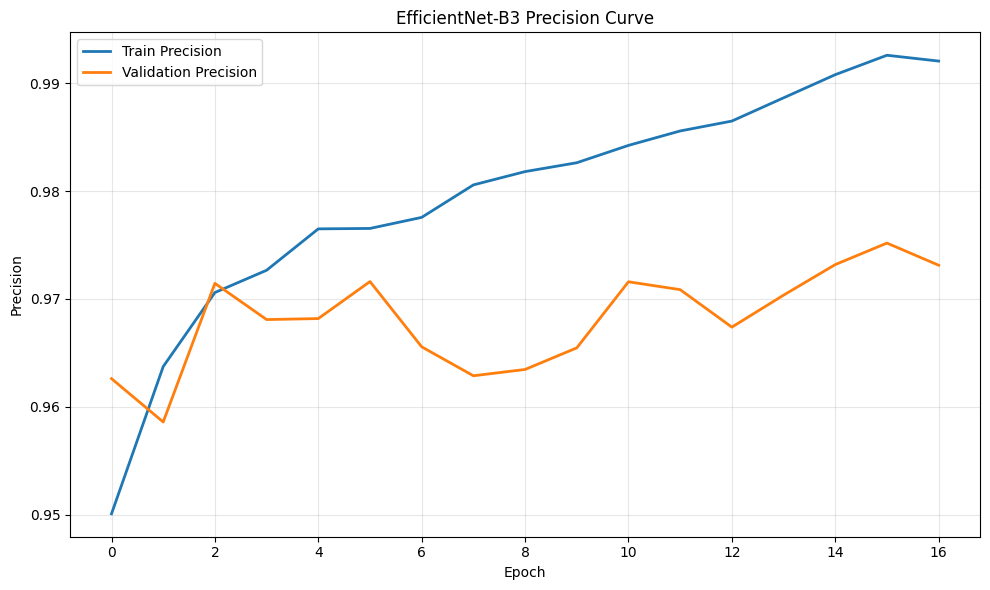

In [70]:
# =====================================================
# PRECISION CURVE
# =====================================================

plt.figure(figsize=(10,6))

plt.plot(
    history["train_precision"],
    label="Train Precision",
    linewidth=2
)

plt.plot(
    history["val_precision"],
    label="Validation Precision",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Precision")

plt.title(
    "EfficientNet-B3 Precision Curve"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

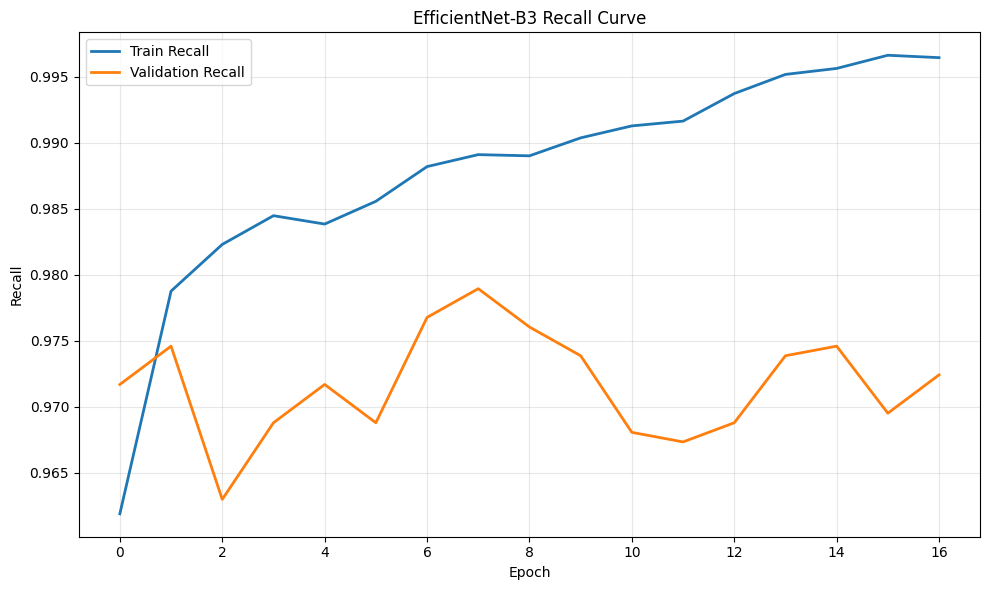

In [71]:
# =====================================================
# RECALL CURVE
# =====================================================

plt.figure(figsize=(10,6))

plt.plot(
    history["train_recall"],
    label="Train Recall",
    linewidth=2
)

plt.plot(
    history["val_recall"],
    label="Validation Recall",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Recall")

plt.title(
    "EfficientNet-B3 Recall Curve"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

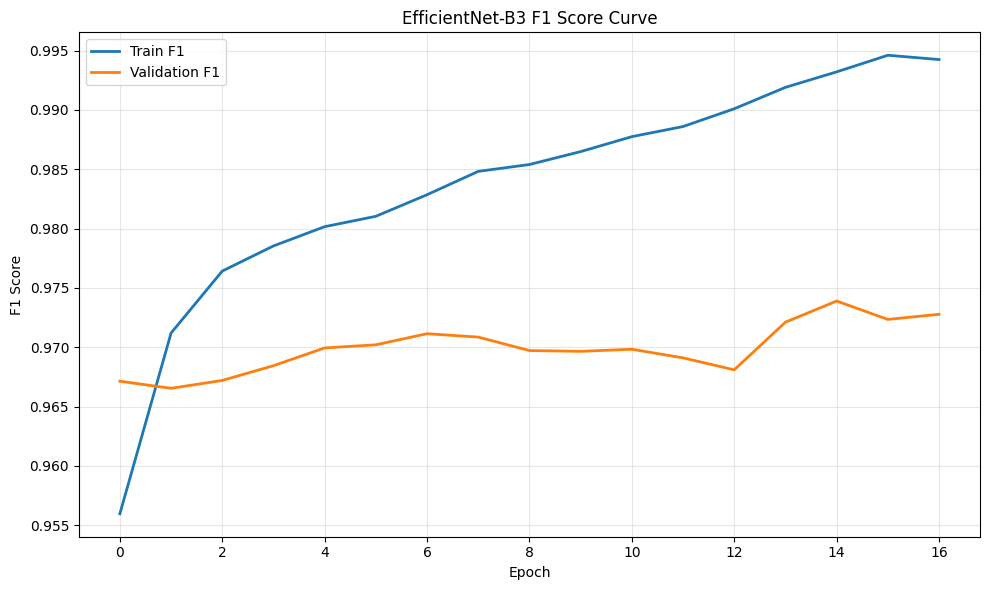

In [72]:
# =====================================================
# F1 SCORE CURVE
# =====================================================

plt.figure(figsize=(10,6))

plt.plot(
    history["train_f1"],
    label="Train F1",
    linewidth=2
)

plt.plot(
    history["val_f1"],
    label="Validation F1",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("F1 Score")

plt.title(
    "EfficientNet-B3 F1 Score Curve"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

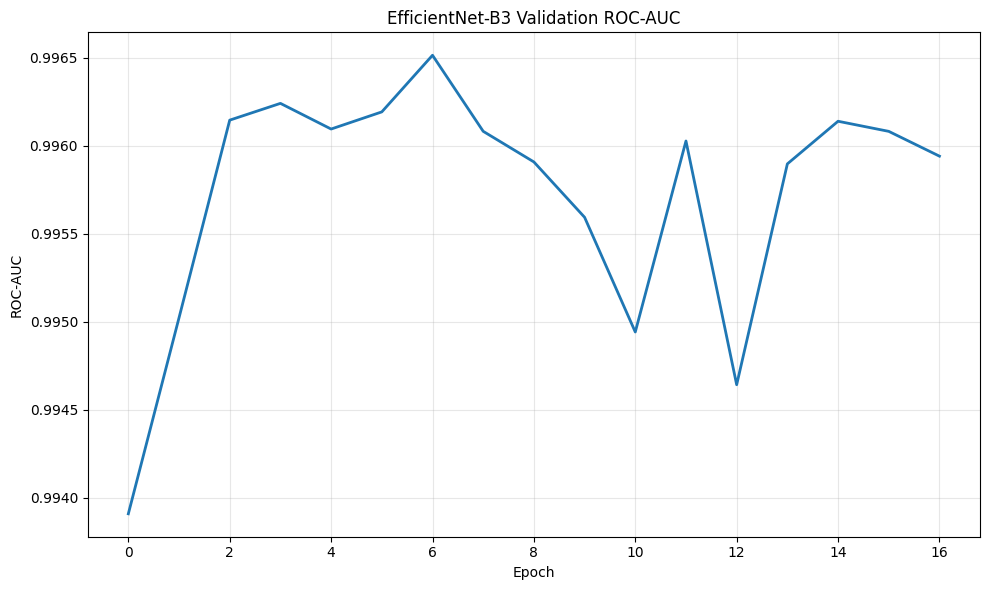

In [73]:
# =====================================================
# AUC CURVE
# =====================================================

plt.figure(figsize=(10,6))

plt.plot(
    history["val_auc"],
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")

plt.title(
    "EfficientNet-B3 Validation ROC-AUC"
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

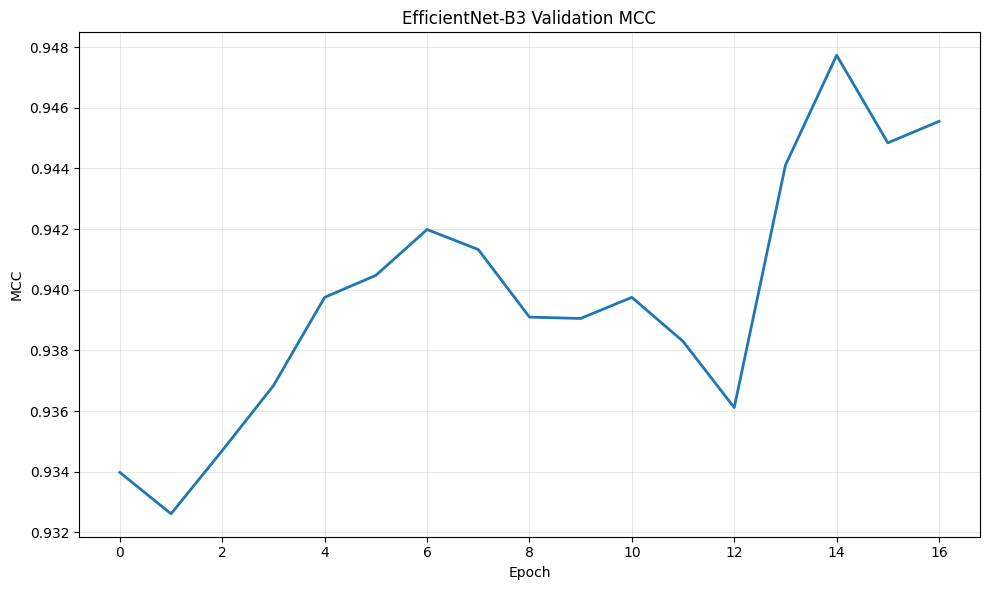

In [74]:
# =====================================================
# MCC CURVE
# =====================================================

plt.figure(figsize=(10,6))

plt.plot(
    history["val_mcc"],
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("MCC")

plt.title(
    "EfficientNet-B3 Validation MCC"
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

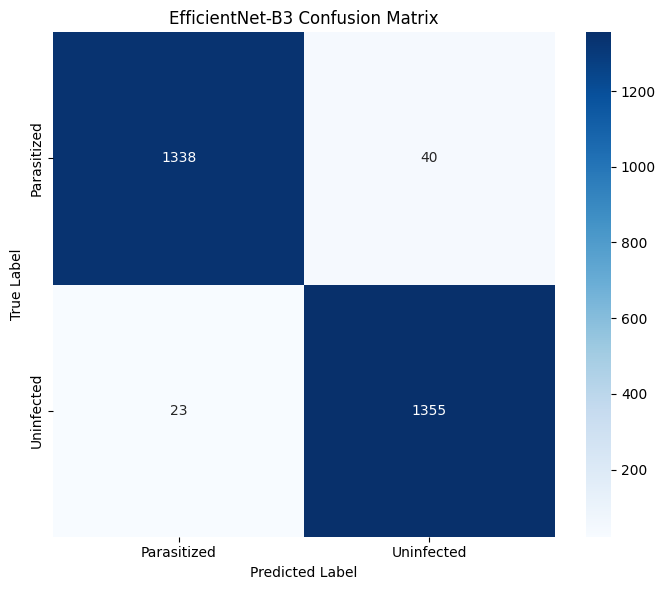

In [75]:
# =====================================================
# CONFUSION MATRIX
# =====================================================

import seaborn as sns

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Parasitized",
        "Uninfected"
    ],
    yticklabels=[
        "Parasitized",
        "Uninfected"
    ]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title(
    "EfficientNet-B3 Confusion Matrix"
)

plt.tight_layout()
plt.show()

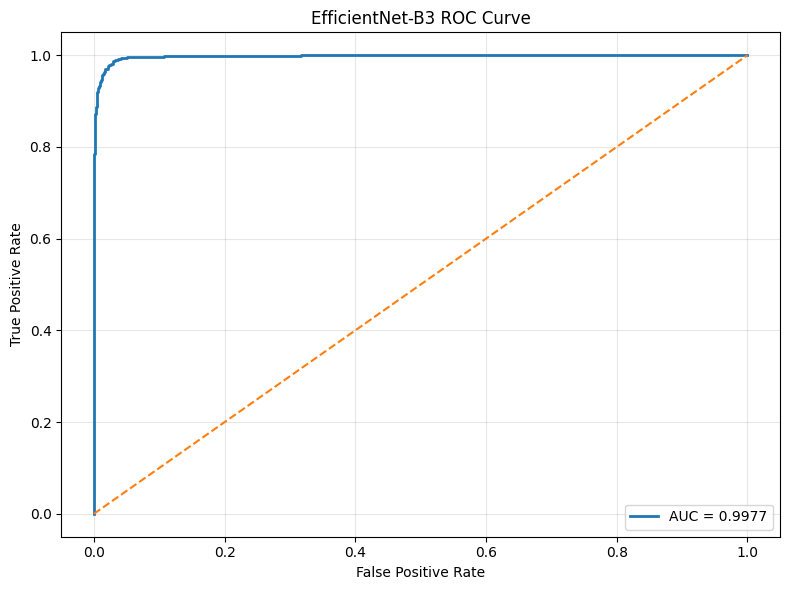

In [76]:
# =====================================================
# ROC CURVE
# =====================================================

from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(
    test_labels,
    test_probs
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {test_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "EfficientNet-B3 ROC Curve"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

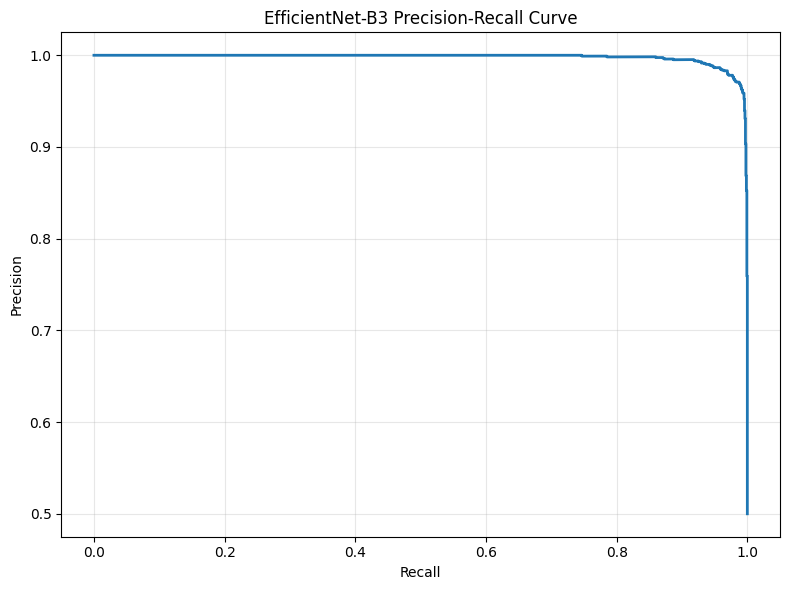

In [77]:
# =====================================================
# PRECISION RECALL CURVE
# =====================================================

from sklearn.metrics import precision_recall_curve

precision_curve, recall_curve, _ = precision_recall_curve(
    test_labels,
    test_probs
)

plt.figure(figsize=(8,6))

plt.plot(
    recall_curve,
    precision_curve,
    linewidth=2
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "EfficientNet-B3 Precision-Recall Curve"
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [78]:
efficientnet_results = {

    "Accuracy": test_acc,
    "Precision": test_precision,
    "Recall": test_recall,
    "F1": test_f1,
    "ROC-AUC": test_auc,
    "MCC": test_mcc
}

In [79]:
# =====================================================
# RESET HISTORY
# =====================================================

history = {

    "train_loss": [],
    "val_loss": [],

    "train_acc": [],
    "val_acc": [],

    "train_precision": [],
    "val_precision": [],

    "train_recall": [],
    "val_recall": [],

    "train_f1": [],
    "val_f1": [],

    "val_auc": [],
    "val_mcc": [],

    "learning_rate": []
}

In [80]:
# =====================================================
# MOBILENETV3-LARGE
# =====================================================

from torchvision import models
import torch.nn as nn

model = models.mobilenet_v3_large(
    weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V1
)

in_features = model.classifier[3].in_features

model.classifier[3] = nn.Linear(
    in_features,
    2
)

model = model.to(device)

print(model.classifier)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 222MB/s]

Sequential(
  (0): Linear(in_features=960, out_features=1280, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1280, out_features=2, bias=True)
)


In [81]:
# =====================================================
# PARAMETER COUNT
# =====================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

Total Parameters: 4,204,594
Trainable Parameters: 4,204,594


In [82]:
# =====================================================
# LOSS + OPTIMIZER
# =====================================================

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=0.05
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.1,
    patience=5
)

print("Optimizer Ready")

Optimizer Ready


In [83]:
# =====================================================
# EARLY STOPPING
# =====================================================

early_stopping = EarlyStopping(
    patience=10,
    save_path="best_mobilenetv3.pth"
)

In [84]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef
)

EPOCHS = 100

for epoch in range(EPOCHS):

    # --------------------------
    # TRAIN
    # --------------------------

    model.train()

    train_loss = 0

    train_preds = []
    train_labels = []

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        preds = outputs.argmax(1)

        train_preds.extend(
            preds.cpu().numpy()
        )

        train_labels.extend(
            labels.cpu().numpy()
        )

    train_loss /= len(train_loader)

    train_acc = accuracy_score(
        train_labels,
        train_preds
    )

    train_precision = precision_score(
        train_labels,
        train_preds
    )

    train_recall = recall_score(
        train_labels,
        train_preds
    )

    train_f1 = f1_score(
        train_labels,
        train_preds
    )

    # --------------------------
    # VALIDATION
    # --------------------------

    model.eval()

    val_loss = 0

    val_preds = []
    val_labels = []
    val_probs = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            val_loss += loss.item()

            probs = torch.softmax(
                outputs,
                dim=1
            )[:,1]

            preds = outputs.argmax(1)

            val_preds.extend(
                preds.cpu().numpy()
            )

            val_labels.extend(
                labels.cpu().numpy()
            )

            val_probs.extend(
                probs.cpu().numpy()
            )

    val_loss /= len(val_loader)

    val_acc = accuracy_score(
        val_labels,
        val_preds
    )

    val_precision = precision_score(
        val_labels,
        val_preds
    )

    val_recall = recall_score(
        val_labels,
        val_preds
    )

    val_f1 = f1_score(
        val_labels,
        val_preds
    )

    val_auc = roc_auc_score(
        val_labels,
        val_probs
    )

    val_mcc = matthews_corrcoef(
        val_labels,
        val_preds
    )

    # --------------------------
    # SAVE HISTORY
    # --------------------------

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    history["train_precision"].append(train_precision)
    history["val_precision"].append(val_precision)

    history["train_recall"].append(train_recall)
    history["val_recall"].append(val_recall)

    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)

    history["val_auc"].append(val_auc)
    history["val_mcc"].append(val_mcc)

    history["learning_rate"].append(
        optimizer.param_groups[0]["lr"]
    )

    scheduler.step(val_loss)

    early_stopping(
        val_loss,
        model
    )

    print(
        f"[{epoch+1:03d}] "
        f"TrainLoss={train_loss:.4f} "
        f"ValLoss={val_loss:.4f} "
        f"Acc={val_acc:.4f} "
        f"F1={val_f1:.4f} "
        f"AUC={val_auc:.4f} "
        f"MCC={val_mcc:.4f}"
    )

    if early_stopping.early_stop:

        print("\nEarly stopping activated.")

        break

[001] TrainLoss=0.1188 ValLoss=0.1181 Acc=0.9619 F1=0.9621 AUC=0.9934 MCC=0.9238
[002] TrainLoss=0.0807 ValLoss=0.1025 Acc=0.9666 F1=0.9668 AUC=0.9940 MCC=0.9332
[003] TrainLoss=0.0716 ValLoss=0.0955 Acc=0.9644 F1=0.9646 AUC=0.9951 MCC=0.9289
[004] TrainLoss=0.0670 ValLoss=0.0928 Acc=0.9641 F1=0.9643 AUC=0.9957 MCC=0.9282
[005] TrainLoss=0.0608 ValLoss=0.1041 Acc=0.9633 F1=0.9638 AUC=0.9934 MCC=0.9269
[006] TrainLoss=0.0577 ValLoss=0.0902 Acc=0.9652 F1=0.9656 AUC=0.9949 MCC=0.9306
[007] TrainLoss=0.0526 ValLoss=0.0824 Acc=0.9713 F1=0.9714 AUC=0.9959 MCC=0.9427
[008] TrainLoss=0.0495 ValLoss=0.0928 Acc=0.9662 F1=0.9662 AUC=0.9959 MCC=0.9325
[009] TrainLoss=0.0486 ValLoss=0.0826 Acc=0.9691 F1=0.9695 AUC=0.9961 MCC=0.9386
[010] TrainLoss=0.0460 ValLoss=0.0875 Acc=0.9662 F1=0.9666 AUC=0.9960 MCC=0.9326
[011] TrainLoss=0.0410 ValLoss=0.0943 Acc=0.9637 F1=0.9642 AUC=0.9955 MCC=0.9278
[012] TrainLoss=0.0389 ValLoss=0.0897 Acc=0.9710 F1=0.9711 AUC=0.9958 MCC=0.9420
[013] TrainLoss=0.0363 ValLo

In [85]:
# =====================================================
# LOAD BEST MODEL
# =====================================================

model.load_state_dict(
    torch.load(
        "best_mobilenetv3.pth"
    )
)

model.eval()

print("Best MobileNetV3 loaded.")

Best MobileNetV3 loaded.


In [86]:
test_acc
test_precision
test_recall
test_f1
test_auc
test_mcc
cm
test_labels
test_preds
test_probs

[np.float32(0.0002902671),
 np.float32(9.365468e-07),
 np.float32(3.5022753e-05),
 np.float32(3.127536e-11),
 np.float32(4.640882e-06),
 np.float32(1.4535914e-10),
 np.float32(1.3519412e-09),
 np.float32(0.033326298),
 np.float32(1.1675782e-12),
 np.float32(1.1792043e-07),
 np.float32(1.3549877e-06),
 np.float32(0.060583696),
 np.float32(1.6893247e-10),
 np.float32(1.9215207e-10),
 np.float32(1.5165624e-05),
 np.float32(0.074209794),
 np.float32(1.6857268e-06),
 np.float32(4.0636663e-09),
 np.float32(9.955086e-06),
 np.float32(2.4343203e-07),
 np.float32(6.5302916e-11),
 np.float32(4.231143e-07),
 np.float32(1.9783819e-12),
 np.float32(8.66014e-07),
 np.float32(5.2054694e-11),
 np.float32(6.9772794e-12),
 np.float32(1.2579979e-10),
 np.float32(1.1626648e-08),
 np.float32(9.6135295e-09),
 np.float32(2.2677585e-12),
 np.float32(2.511763e-10),
 np.float32(0.74739426),
 np.float32(0.013305852),
 np.float32(0.9933351),
 np.float32(2.0607713e-06),
 np.float32(0.00017199152),
 np.float32(1.89

In [87]:
mobilenet_results = {

    "Accuracy": test_acc,
    "Precision": test_precision,
    "Recall": test_recall,
    "F1": test_f1,
    "ROC-AUC": test_auc,
    "MCC": test_mcc
}

In [88]:
import pandas as pd

MobileNetV3_results = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "MCC"
    ],

    "MobileNetV3":[

        test_acc,
        test_precision,
        test_recall,
        test_f1,
        test_auc,
        test_mcc
    ]
})

MobileNetV3_results

,Metric,MobileNetV3
0,Accuracy,0.977141
1,Precision,0.971326
2,Recall,0.983309
3,F1 Score,0.977281
4,ROC-AUC,0.997687
5,MCC,0.954354


In [89]:
MobileNetV3_results.to_csv(
    "MobileNetV3_Test_Results.csv",
    index=False
)

print("Results Saved.")

Results Saved.


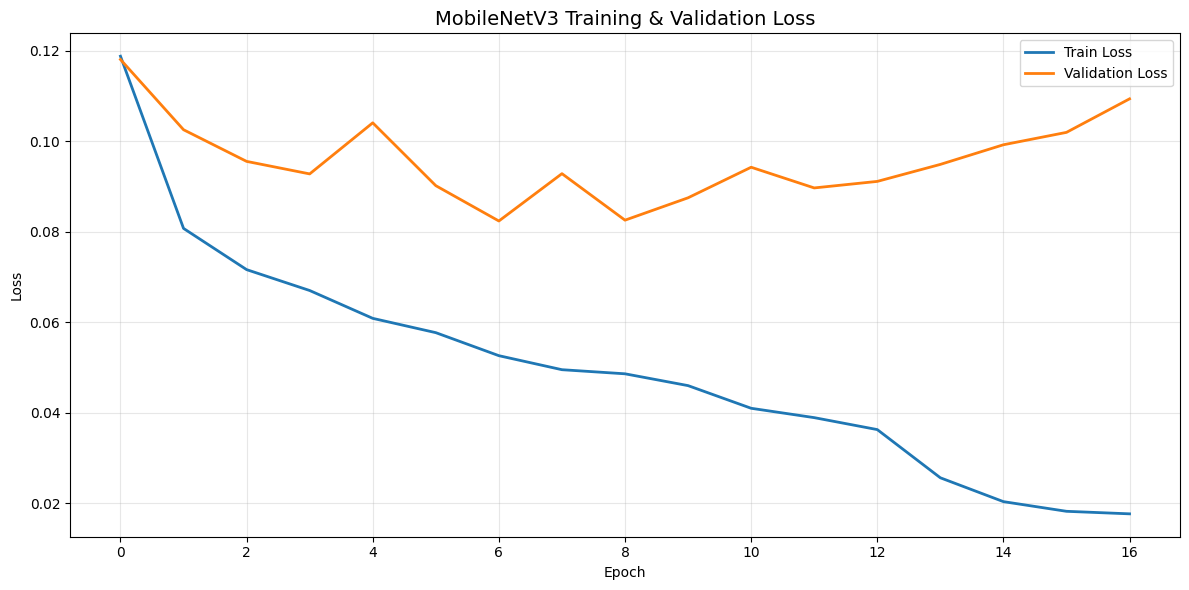

In [90]:
# =====================================================
# MOBILENETV3 LOSS CURVE
# =====================================================

plt.figure(figsize=(12,6))

plt.plot(
    history["train_loss"],
    label="Train Loss",
    linewidth=2
)

plt.plot(
    history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.title(
    "MobileNetV3 Training & Validation Loss",
    fontsize=14
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

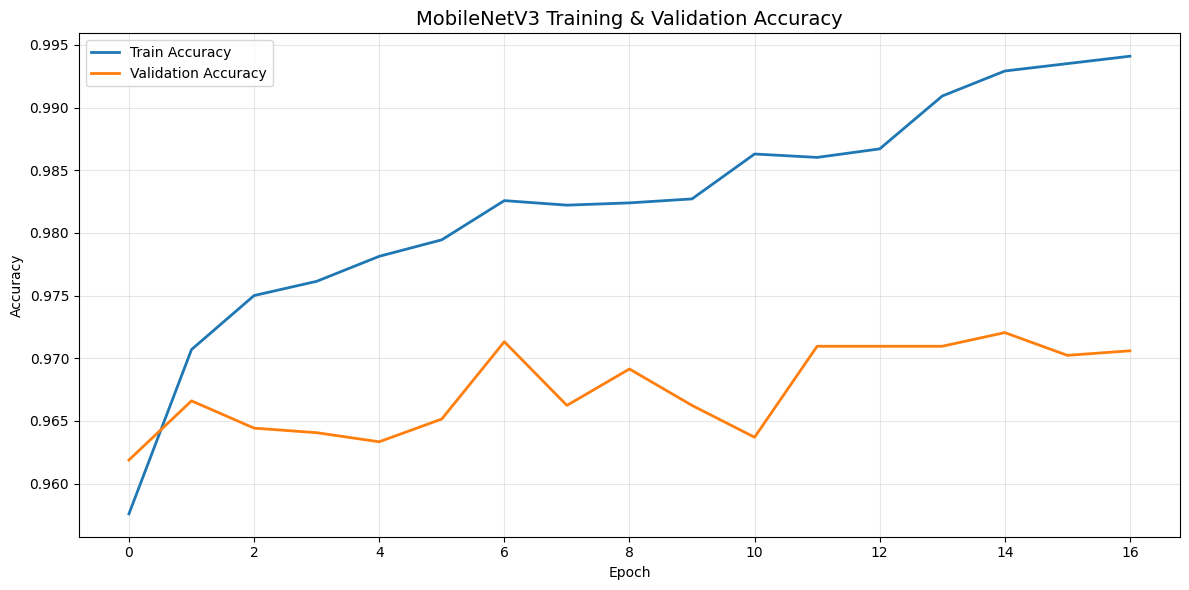

In [91]:
# =====================================================
# MOBILENETV3 ACCURACY CURVE
# =====================================================

plt.figure(figsize=(12,6))

plt.plot(
    history["train_acc"],
    label="Train Accuracy",
    linewidth=2
)

plt.plot(
    history["val_acc"],
    label="Validation Accuracy",
    linewidth=2
)

plt.title(
    "MobileNetV3 Training & Validation Accuracy",
    fontsize=14
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

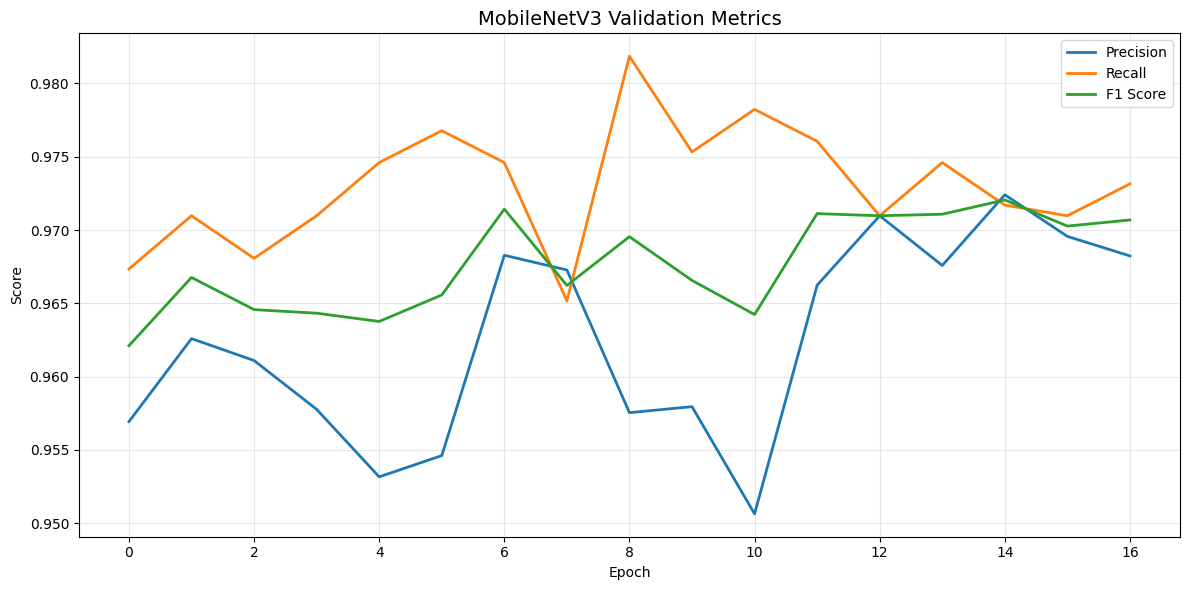

In [92]:
# =====================================================
# PRECISION RECALL F1
# =====================================================

plt.figure(figsize=(12,6))

plt.plot(
    history["val_precision"],
    label="Precision",
    linewidth=2
)

plt.plot(
    history["val_recall"],
    label="Recall",
    linewidth=2
)

plt.plot(
    history["val_f1"],
    label="F1 Score",
    linewidth=2
)

plt.title(
    "MobileNetV3 Validation Metrics",
    fontsize=14
)

plt.xlabel("Epoch")
plt.ylabel("Score")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

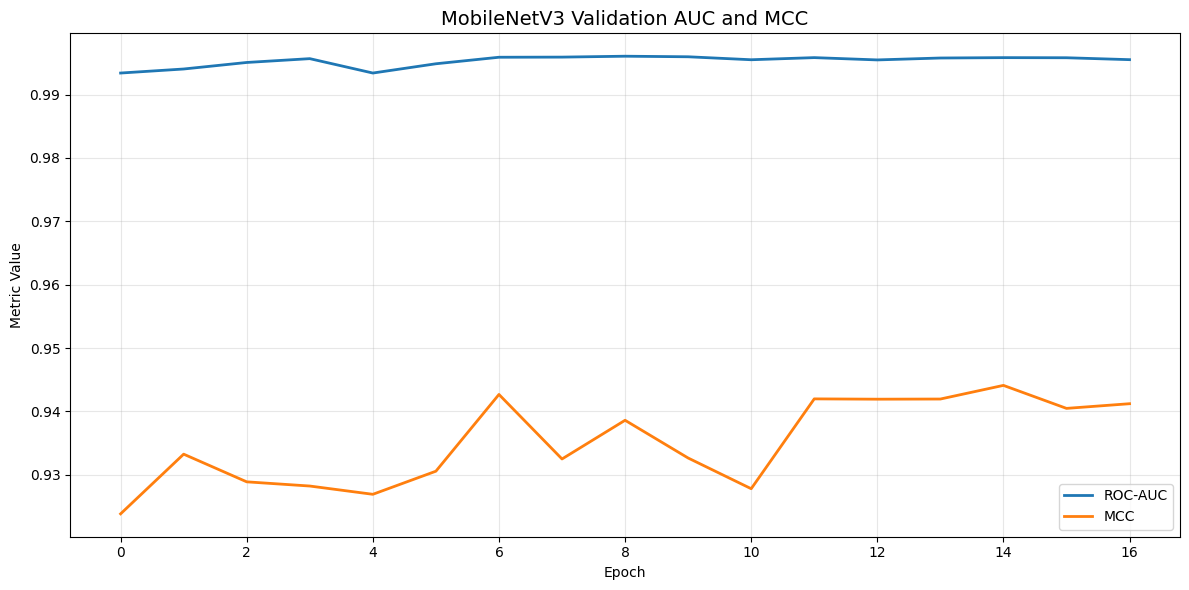

In [93]:
# =====================================================
# AUC & MCC
# =====================================================

plt.figure(figsize=(12,6))

plt.plot(
    history["val_auc"],
    label="ROC-AUC",
    linewidth=2
)

plt.plot(
    history["val_mcc"],
    label="MCC",
    linewidth=2
)

plt.title(
    "MobileNetV3 Validation AUC and MCC",
    fontsize=14
)

plt.xlabel("Epoch")
plt.ylabel("Metric Value")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

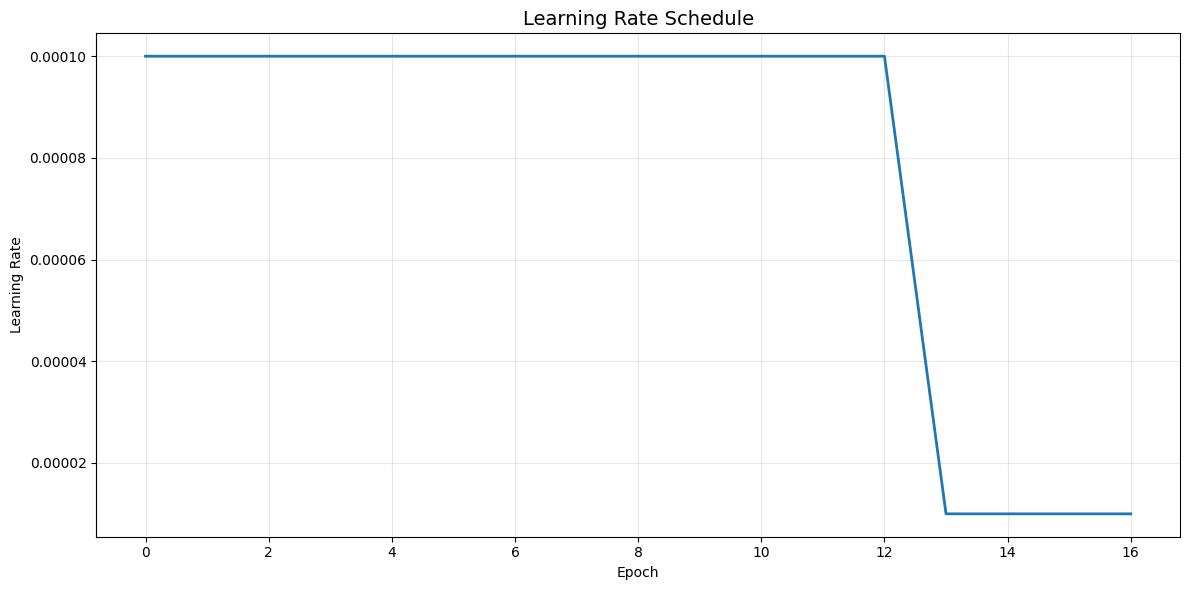

In [94]:
# =====================================================
# LEARNING RATE
# =====================================================

plt.figure(figsize=(12,6))

plt.plot(
    history["learning_rate"],
    linewidth=2
)

plt.title(
    "Learning Rate Schedule",
    fontsize=14
)

plt.xlabel("Epoch")
plt.ylabel("Learning Rate")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

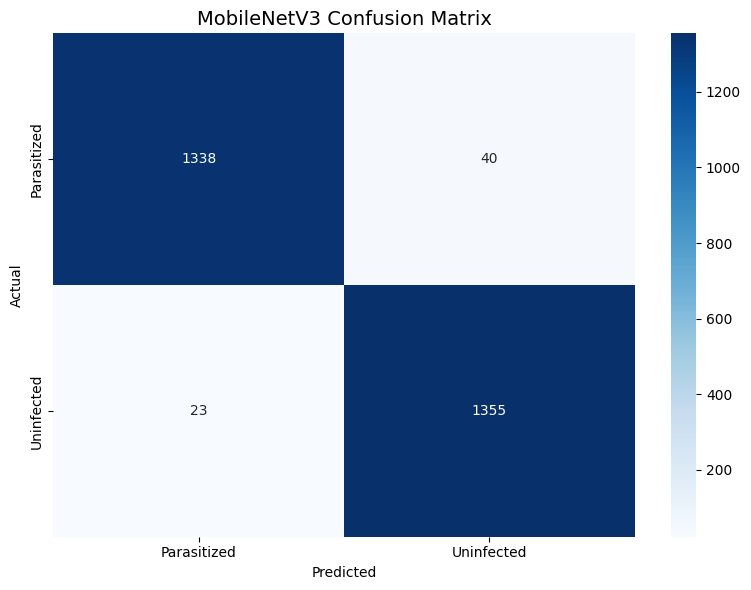

In [95]:
# =====================================================
# CONFUSION MATRIX
# =====================================================

import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Parasitized",
        "Uninfected"
    ],
    yticklabels=[
        "Parasitized",
        "Uninfected"
    ]
)

plt.title(
    "MobileNetV3 Confusion Matrix",
    fontsize=14
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

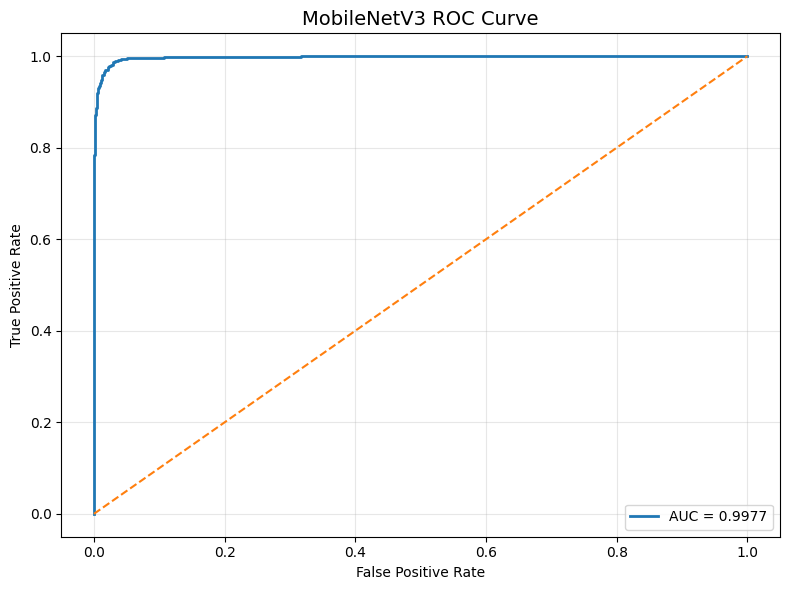

In [96]:
# =====================================================
# ROC CURVE
# =====================================================

from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(
    test_labels,
    test_probs
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {test_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "MobileNetV3 ROC Curve",
    fontsize=14
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

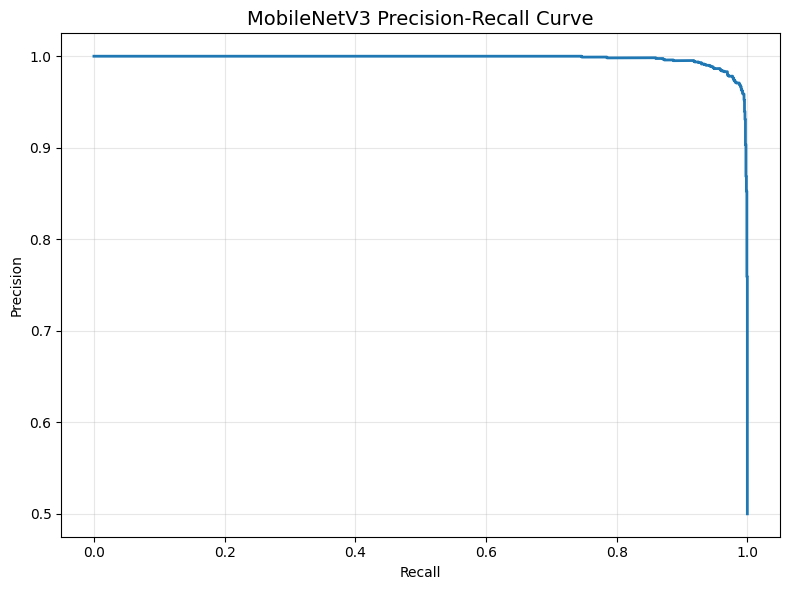

In [97]:
# =====================================================
# PRECISION RECALL CURVE
# =====================================================

from sklearn.metrics import precision_recall_curve

precision_curve, recall_curve, _ = precision_recall_curve(
    test_labels,
    test_probs
)

plt.figure(figsize=(8,6))

plt.plot(
    recall_curve,
    precision_curve,
    linewidth=2
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "MobileNetV3 Precision-Recall Curve",
    fontsize=14
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()